# Integrated Finance Analysis — Hydro_EU — iNPV · S-IRR · WACC Adjustment

Extends the supply-chain and nature-dependency footprint (Parts A–C of
`investment_analysis.ipynb`) into a full integrated finance model.

**Source documents used in this notebook:**
- `results/final_analysis.md` — Portfolio GHG and FTE totals across all SSPs
- `results/scenario_adjustment.csv` — Calibrated SSP adjustment factors per project
- `results/dependency_summary.csv` — WWF water risk and revenue-at-risk scores
- `source/natural_capital_npv_sensitivity_framework.md` — ONPV formula derivation
- `source/natural_capital_npv_sensitivity_summary.md` — Three-channel risk model
- `source/onpv_formula_corrected.md` — Known formula gaps (P1–P8)

| Horizon | Duration |
|---------|----------|
| **Bond lifetime** | 10 years |
| **Project lifetime** | 30 years |

**Part A** — Re-run IO analysis and WifOR monetisation (same as investment_analysis.ipynb)  
**Part B** — Societal cash-flow construction over the full 30-year horizon  
**Part C** — Integrated NPV (iNPV) vs standard NPV across discount rates  
**Part D** — Societal IRR (S-IRR): the rate at which total value breaks even  
**Part E** — WACC adjustment via nature-dependency profile  
**Part F** — Combined cash-flow table and integrated Matplotlib dashboard  
**Part G** — Multi-scenario IPCC comparison (all five SSPs)  

> **Project:** Hydro_EU | Energy | Europe | CAPEX $2.0 M | Avoided CO₂: 6,126 tCO₂e/yr  
> **Note on SCC:** WifOR value factors use the Nordhaus DICE baseline (~$19/tCO₂e).
> The IPCC AR6 WG3 central estimate is $171/tCO₂e. All nature-debt and iNPV figures
> are therefore conservative lower bounds. See **Plausibility Assessment** before Part F.


In [1]:
# ══════════════════════════════════════════════════════════════════
# PARAMETERS  ← auto-generated for Hydro_EU
# Small efficiency tweak; 6,126 tCO2e/yr avoided; European low-carbon grid
# ══════════════════════════════════════════════════════════════════
from pathlib import Path

# ── Project / IO parameters ───────────────────────────────────────
CAPEX_USD    = 2_000_000       # Project CAPEX (USD)
COUNTRY      = "DE"              # ISO-2 / broad region → REGION_TO_ISO3
SECTOR       = "Energy"        # IO sector key
DATABASE     = "exiobase"
SCENARIO     = "SSP2-4.5"       # default SSP scenario
FOCUS_YEAR   = 2030
# Notebooks live in integrated_finance/ (one level below project_assessment/)
RESULTS_DIR  = Path("../results")       # → project_assessment/results/
REPO_ROOT    = Path(".").resolve().parent.parent  # → tvp5/
TOP_N        = 5

# ── Integrated finance parameters ────────────────────────────────
BOND_YEARS         = 5          # Bond lifetime (years)
PROJECT_YEARS      = 20          # Operational lifetime (years)
WACC_BASE          = 0.060       # Base WACC
REVENUE_YIELD      = 0.10        # Annual revenue fraction of CAPEX
OPEX_RATIO         = 0.04        # Annual OPEX fraction of CAPEX

ANNUAL_AVOIDED_CO2_tCO2e = 6_126   # tCO2e / year (0 if N/A)

ESG_MAX_DISCOUNT   = 0.0010      # 10 bps maximum WACC sustainability discount

print(f"Project          : Hydro_EU")
print(f"Bond lifetime    : {BOND_YEARS} years")
print(f"Project lifetime : {PROJECT_YEARS} years")
print(f"CAPEX            : ${CAPEX_USD/1e6:.1f} M")
print(f"WACC base        : {WACC_BASE*100:.2f} %")
print(f"Revenue yield    : {REVENUE_YIELD*100:.1f} % of CAPEX/yr")
print(f"OPEX ratio       : {OPEX_RATIO*100:.1f} % of CAPEX/yr")
print(f"Avoided CO₂      : {ANNUAL_AVOIDED_CO2_tCO2e:,} tCO₂e/yr")


Project          : Hydro_EU
Bond lifetime    : 5 years
Project lifetime : 20 years
CAPEX            : $2.0 M
WACC base        : 6.00 %
Revenue yield    : 10.0 % of CAPEX/yr
OPEX ratio       : 4.0 % of CAPEX/yr
Avoided CO₂      : 6,126 tCO₂e/yr


In [2]:
# ==================================================================
# CALIBRATION -- Real portfolio data vs modelled parameters
# Project: Hydro_EU
# ==================================================================
import pathlib, warnings
import pandas as pd
from IPython.display import display, HTML

_BASE    = pathlib.Path('..')  # integrated_finance/ → project_assessment/
PROJ_ID  = 'Hydro_EU'
YEAR_CAL = 2030

# -- Load scenario adjustment factors ---------------------------------
try:
    sa = pd.read_csv(_BASE / 'results/scenario_adjustment.csv')
    sa_proj = sa[
        (sa['project_id'] == PROJ_ID) &
        (sa['year'] == YEAR_CAL)
    ][['scenario','adj_ratio_ghg','adj_ratio_employment','adj_ratio_water']].copy()
    sa_proj.columns = ['SSP','adj_ghg','adj_employment','adj_water']
    sa_proj = sa_proj.sort_values('SSP').reset_index(drop=True)
    print(f'Scenario adjustment factors  --  {PROJ_ID} @ year {YEAR_CAL}:')
    display(sa_proj.to_html(index=False, float_format=lambda x: f'{x:.4f}'))
except FileNotFoundError:
    warnings.warn('scenario_adjustment.csv not found -- skipping')
    sa_proj = pd.DataFrame()

# -- Load dependency summary ------------------------------------------
try:
    ds = pd.read_csv(_BASE / 'results/dependency_summary.csv')
    ds_proj = ds[ds['project_id'] == PROJ_ID]
    if ds_proj.empty:
        ds_proj = ds.head(1)
    cols = ['project_id','wrf_physical','wrf_composite','brf_composite',
            'overall_high_risk','revenue_at_risk_usd_m','top_dependency']
    cols = [c for c in cols if c in ds_proj.columns]
    print(f'\nNature-dependency scores  --  {PROJ_ID}:')
    display(ds_proj[cols].to_html(index=False))
except FileNotFoundError:
    warnings.warn('dependency_summary.csv not found -- skipping')
    ds_proj = pd.DataFrame()

# -- Plausibility check HTML table ------------------------------------
_html = "<h3>Plausibility Check &#8212; Hydro_EU vs Portfolio Data &amp; Literature</h3>\n<style>\n.plaus td, .plaus th { padding:5px 10px; border:1px solid #ccc; font-size:13px; }\n.plaus th { background:#2c3e50; color:#fff; }\n.plaus .ok  { background:#d5f5e3; }\n.plaus .warn{ background:#fdebd0; }\n.plaus .err { background:#fadbd8; }\n</style>\n<table class='plaus'>\n<tr><th>Parameter</th><th>Notebook value</th><th>Source</th><th>Status</th></tr>\n<tr class='ok'><td>CAPEX (USD)</td><td>$2.0 M</td><td>modeled_input_data input CSV</td><td>OK &#8212; direct from input data</td></tr>\n<tr class='ok'><td>WACC_BASE</td><td>6.0%</td><td>Sector/region risk-adjusted; infra WACC 5&#8211;9%</td><td>OK &#8212; region-adjusted for Europe</td></tr>\n<tr class='warn'><td>SCC &#8212; GHG (c_ghg)</td><td>~$19/tCO&#8322;e (Nordhaus)</td><td>IPCC AR6 WG3 central: $171/tCO&#8322;e</td><td>CONSERVATIVE &#8212; outputs are lower bounds</td></tr>\n<tr class='err'><td>Legal risk (L_legal)</td><td>Not modelled</td><td>Wetzer et al. (Science 383:152, 2024)</td><td>GAP &#8212; understates downside risk</td></tr>\n</table>"
display(HTML(_html))


Scenario adjustment factors  --  Hydro_EU @ year 2030:


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>SSP</th>\n      <th>adj_ghg</th>\n      <th>adj_employment</th>\n      <th>adj_water</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>SSP1-1.9</td>\n      <td>0.3128</td>\n      <td>1.1760</td>\n      <td>0.3419</td>\n    </tr>\n    <tr>\n      <td>SSP2-4.5</td>\n      <td>0.6700</td>\n      <td>1.1128</td>\n      <td>0.5877</td>\n    </tr>\n    <tr>\n      <td>SSP3-7.0</td>\n      <td>0.8286</td>\n      <td>1.0400</td>\n      <td>0.7443</td>\n    </tr>\n    <tr>\n      <td>SSP4-6.0</td>\n      <td>0.3368</td>\n      <td>1.1680</td>\n      <td>0.3624</td>\n    </tr>\n    <tr>\n      <td>SSP5-8.5</td>\n      <td>0.8419</td>\n      <td>1.0120</td>\n      <td>0.7807</td>\n    </tr>\n  </tbody>\n</table>'


Nature-dependency scores  --  Hydro_EU:


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>project_id</th>\n      <th>wrf_physical</th>\n      <th>wrf_composite</th>\n      <th>brf_composite</th>\n      <th>overall_high_risk</th>\n      <th>revenue_at_risk_usd_m</th>\n      <th>top_dependency</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Hydro_EU</td>\n      <td>3.17</td>\n      <td>3.622</td>\n      <td>3.231</td>\n      <td>True</td>\n      <td>0.85</td>\n      <td>water_supply</td>\n    </tr>\n  </tbody>\n</table>'

Parameter,Notebook value,Source,Status
CAPEX (USD),$2.0 M,modeled_input_data input CSV,OK — direct from input data
WACC_BASE,6.0%,Sector/region risk-adjusted; infra WACC 5–9%,OK — region-adjusted for Europe
SCC — GHG (c_ghg),~$19/tCO₂e (Nordhaus),IPCC AR6 WG3 central: $171/tCO₂e,CONSERVATIVE — outputs are lower bounds
Legal risk (L_legal),Not modelled,"Wetzer et al. (Science 383:152, 2024)",GAP — understates downside risk


In [3]:
# ══════════════════════════════════════════════════════════════════
# IMPORTS, COLOUR PALETTES, DEP CONSTANTS
# ══════════════════════════════════════════════════════════════════
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
from scipy.optimize import brentq

sys.path.insert(0, str(REPO_ROOT / "tvp_dbio"))
sys.path.insert(0, str(REPO_ROOT / "tvp_dependency"))
sys.path.insert(0, str(REPO_ROOT / "project_assessment"))

from tvp_io_lib import (
    tier0_impact, tier1_impact, tier_impact,
    ISO2_TO_REGION, SECTOR_ALLOC,
)
from dependency_profiler.encore_materiality import (
    MATERIALITY_MATRIX, RATING_SCALE, ECOSYSTEM_SERVICES,
    get_materiality_profile,
)
from dependency_profiler.wwf_risk_filter import (
    score_project, REGIONAL_BASELINES, HIGH_RISK_THRESHOLD,
)
from assess import (
    PROJECT_SECTOR_TO_ENCORE,
    STRESSOR_ECOSYSTEM_MAP,
    STRESSOR_WWF_COL,
    STRESSOR_SC_DEP_KEY,
    SC_SECTOR_DEP_PROFILE,
    DEP_NEUTRAL,
    REGION_TO_ISO3,
    PROJECT_SECTOR_TO_NACE,
    VF_FILE_SPECS,
    FTE_HOURS_PER_YEAR,
    _resolve_wifor_dir,
    _load_vf_coeff,
)

SC_SECTOR_DEP  = SC_SECTOR_DEP_PROFILE
STRESSOR_SC_KEY = STRESSOR_SC_DEP_KEY
DEP_THRESHOLD  = HIGH_RISK_THRESHOLD

# ── Colour palettes ────────────────────────────────────────────────
TIER_NODE = {"t0": "#4e79a7", "t1": "#f28e2b", "t2": "#59a14f", "t3": "#b07aa1"}
C_NEG     = "#d62728"   # costs / negative impacts
C_POS     = "#2ca02c"   # benefits / positive impacts
C_FIN     = "#4e79a7"   # financial cash flows
C_GHG     = "#e07070"   # GHG monetised
C_EMP     = "#2ca02c"   # employment monetised
C_WAT     = "#1f77b4"   # water monetised
C_TOT     = "#6b4c9a"   # total / integrated
SSP_COLORS = {           # per-SSP palette (green=ambitious → red=fossil-heavy)
    'SSP1-1.9': '#1a9641',
    'SSP2-4.5': '#a6d96a',
    'SSP3-7.0': '#fdae61',
    'SSP4-6.0': '#ffffbf',
    'SSP5-8.5': '#d73027',
}
ALL_SSPS   = ["SSP1-1.9","SSP2-4.5","SSP3-7.0","SSP4-6.0","SSP5-8.5"]
INTENSITY_CSV = REPO_ROOT / "tvp_scenario" / "osemosys" / "results" / "tvpdbio_intensity_factors.csv"

COUNTRY_NAMES = {
    "germany":"DE","france":"FR","uk":"GB","united kingdom":"GB",
    "spain":"ES","italy":"IT","netherlands":"NL","poland":"PL",
    "sweden":"SE","norway":"NO","switzerland":"CH","turkey":"TR",
    "brazil":"BR","mexico":"MX","argentina":"AR","colombia":"CO",
    "chile":"CL","peru":"PE","south africa":"ZA","nigeria":"NG",
    "kenya":"KE","ethiopia":"ET","ghana":"GH","egypt":"EG","morocco":"MA",
    "china":"CN","india":"IN","japan":"JP","south korea":"KR",
    "indonesia":"ID","thailand":"TH","vietnam":"VN",
    "russia":"RU","united states":"US","usa":"US","canada":"CA","australia":"AU",
}

def resolve(country):
    u = country.strip().upper()
    if u in ISO2_TO_REGION: return ISO2_TO_REGION[u]
    rm = {r.upper(): r for r in ("Europe","LATAM","Africa","Asia","Global")}
    if u in rm: return rm[u]
    iso2 = COUNTRY_NAMES.get(country.strip().lower())
    return ISO2_TO_REGION.get(iso2, "Global") if iso2 else "Global"

def fmt_capex(v):
    return f"${v/1e9:.2f}B" if v >= 1e9 else f"${v/1e6:.1f}M" if v >= 1e6 else f"${v:,.0f}"

REGION        = resolve(COUNTRY)
ENCORE_SECTOR = PROJECT_SECTOR_TO_ENCORE.get(SECTOR, "rail_transport")
DEP_REGION    = REGION.lower() if REGION.lower() in REGIONAL_BASELINES else "europe"
print(f"Country: {COUNTRY} → Region: {REGION}  |  ENCORE: {ENCORE_SECTOR}")

Country: DE → Region: Europe  |  ENCORE: electric_power_generation_hydro


In [4]:
# ══════════════════════════════════════════════════════════════════
# IO ANALYSIS  (Leontief tiers 0-10)
# ══════════════════════════════════════════════════════════════════
print("[1/4] Tier 0 ...", end=" ", flush=True)
t0_res = tier0_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t0_res['GHG_tCO2e']:,.0f}")

print("[2/4] Tier 1 bilateral ...", end=" ", flush=True)
t1_res = tier1_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t1_res['GHG_tCO2e']:,.0f}")

print("[3/4] Tier 2 ...", end=" ", flush=True)
t2_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=2, tier_to=2)
print(f"{len(t2_raw)} rows")

print("[4/4] Tier 3-10 ...", end=" ", flush=True)
t3_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=3, tier_to=10)
print(f"{len(t3_raw)} rows")

PID = f"{SECTOR}_{REGION}_{fmt_capex(CAPEX_USD)}"

def _t0_df():
    rows = [{"project_id": PID, "supplying_sector": sec,
              **{k: v for k, v in vals.items() if k != "spend_M$"}}
             for sec, vals in t0_res["impact_by_sector"].items()]
    return pd.DataFrame(rows)

def _t1_df():
    rows = [{"project_id": PID, "supplying_sector": sec, "sourcing_region": reg,
              **{k: v for k, v in rv.items() if k not in ("share", "spend_M$")}}
             for sec, regions in t1_res["tier1_by_sector"].items()
             for reg, rv in regions.items()]
    return pd.DataFrame(rows)

t0 = _t0_df(); t1 = _t1_df()
t2 = t2_raw.copy(); t2["project_id"] = PID
t3 = t3_raw.copy(); t3["project_id"] = PID

COLS_SC = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]
print(f"\n{'Stressor':<22} {'T0':>10} {'T1':>10} {'T2':>10} {'T3-10':>10} {'Total':>12}")
print("-" * 70)
for c in COLS_SC:
    v = [df[c].sum() if c in df.columns else 0 for df in [t0, t1, t2, t3]]
    print(f"  {c:<20} {v[0]:>10,.0f} {v[1]:>10,.0f} {v[2]:>10,.0f} {v[3]:>10,.0f} {sum(v):>12,.0f}")

[1/4] Tier 0 ... 

GHG 392
[2/4] Tier 1 bilateral ... 

GHG 228
[3/4] Tier 2 ... 

40 rows
[4/4] Tier 3-10 ... 

320 rows

Stressor                       T0         T1         T2      T3-10        Total
----------------------------------------------------------------------
  GHG_tCO2e                   392        228        106         92          818
  Employment_FTE               13          8          4          3           28
  Water_1000m3                  2          2          1          1            5
  ValueAdded_M$                 1          1          0          0            2


In [5]:
# ══════════════════════════════════════════════════════════════════
# SCENARIO FACTORS + DEPENDENCY SETUP
# ══════════════════════════════════════════════════════════════════
def _load_factors(region, scenario, year):
    if not INTENSITY_CSV.exists() or scenario is None: return None
    df  = pd.read_csv(INTENSITY_CSV)
    row = df[(df["region"]==region)&(df["scenario"]==scenario)&(df["year"]==float(year))]
    if row.empty: return None
    r  = row.iloc[0]
    rs = float(r.get("renewable_share", 0.5))
    return {
        "GHG_tCO2e":      float(r["adj_ratio_ghg"]),
        "Employment_FTE": float(r["adj_ratio_employment"]),
        "Water_1000m3":   float(rs * 0.15 + (1 - rs) * 1.0),
        "ValueAdded_M$":  float(r["adj_ratio_employment"]),
    }

def _apply(val, col, factors):
    return val * factors[col] if (factors and col in factors) else val

FACTORS  = _load_factors(REGION, SCENARIO, FOCUS_YEAR)
sc_label = f"{SCENARIO} {FOCUS_YEAR}" if SCENARIO and FACTORS else "Baseline"

# ── ENCORE dependency scores ───────────────────────────────────────
_enc_profile = get_materiality_profile(ENCORE_SECTOR)
ENCORE_DEP   = {}
for stressor, svcs in STRESSOR_ECOSYSTEM_MAP.items():
    _dep_scores = [_enc_profile.ratings.get(svc, {}).get("dependency_score", 0)
                   for svc in svcs]
    ENCORE_DEP[stressor] = sum(_dep_scores) / max(len(_dep_scores), 1)

# ── WWF scores ────────────────────────────────────────────────────
WWF_BY_REGION = {}
for _dep_reg in REGIONAL_BASELINES:
    _res = score_project(f"_dyn_{_dep_reg}", _dep_reg, ENCORE_SECTOR)
    WWF_BY_REGION[_dep_reg] = {
        "wrf_physical":        _res.wrf.physical,
        "wrf_regulatory":      _res.wrf.regulatory,
        "wrf_reputational":    _res.wrf.reputational,
        "wrf_composite":       _res.wrf.composite,
        "brf_species_threat":  _res.brf.species_threat,
        "brf_ecosystem":       _res.brf.ecosystem_intactness,
        "brf_protected_areas": _res.brf.protected_areas,
        "brf_composite":       _res.brf.composite,
    }

def get_wwf(region_str):
    key = (region_str or "").lower()
    return WWF_BY_REGION.get(key, WWF_BY_REGION.get("europe", {}))

def dep_factor(stressor, sourcing_region, supplying_sector):
    enc  = ENCORE_DEP.get(stressor, DEP_NEUTRAL)
    wwf  = get_wwf(sourcing_region).get(STRESSOR_WWF_COL[stressor], DEP_NEUTRAL)
    sc   = SC_SECTOR_DEP.get(supplying_sector, {}).get(STRESSOR_SC_KEY[stressor], DEP_NEUTRAL)
    base = (enc/DEP_NEUTRAL + wwf/DEP_NEUTRAL) / 2.0
    return (base + sc/DEP_NEUTRAL) / 2.0

# ── Tier-level weighted dep_factor ────────────────────────────────
TIER_DEP = {}
for tier_key, df, region_col in [
    ("t0", t0, None),
    ("t1", t1, "sourcing_region"),
    ("t2", t2, None),
    ("t3", t3, None),
]:
    TIER_DEP[tier_key] = {}
    for st in COLS_SC:
        if st not in df.columns or df.empty:
            TIER_DEP[tier_key][st] = 1.0
            continue
        weights = np.abs(df[st].values) + 1e-9
        factors = [
            dep_factor(st,
                       row.get(region_col, REGION) if region_col else REGION,
                       row["supplying_sector"])
            for _, row in df.iterrows()
        ]
        TIER_DEP[tier_key][st] = float(np.average(factors, weights=weights))

def _raw(df, c): return df[c].sum() if c in df.columns else 0.0
def _adj(df, c): return _apply(_raw(df, c), c, FACTORS)

TIER_DEFS = [("t0","Tier 0  Direct",t0),
              ("t1","Tier 1  Bilateral",t1),
              ("t2","Tier 2  Upstream",t2),
              ("t3","Tier 3-10  Deep",t3)]

SUMMARY = {}
for tk, _, df in TIER_DEFS:
    SUMMARY[tk] = {
        "raw": {c: _raw(df, c) for c in COLS_SC},
        "adj": {c: _adj(df, c) for c in COLS_SC},
        "dep": {c: _adj(df, c) * TIER_DEP[tk][c] for c in COLS_SC},
    }
GRAND = {
    layer: {c: sum(SUMMARY[tk][layer][c] for tk, *_ in TIER_DEFS)
            for c in COLS_SC}
    for layer in ["raw", "adj", "dep"]
}

print(f"Scenario adjustment: {sc_label}")
for layer in ["raw", "adj"]:
    print(f"  GRAND [{layer}]  GHG={GRAND[layer]['GHG_tCO2e']:,.0f} tCO₂e  "
          f"FTE={GRAND[layer]['Employment_FTE']:,.0f}  "
          f"Water={GRAND[layer]['Water_1000m3']:,.0f} k m³")

# ── Load adjustment factors for ALL SSP scenarios ─────────────────────
ALL_FACTORS = {s: _load_factors(REGION, s, FOCUS_YEAR) for s in ALL_SSPS}
_avail = [s for s, f in ALL_FACTORS.items() if f is not None]
print(f"\nSSP factors loaded for {REGION} @ {FOCUS_YEAR}: "
      f"{len(_avail)}/{len(ALL_SSPS)} scenarios available → {_avail}")
if _avail:
    print(f"  Factor range (GHG adj_ratio): "
          f"{min(ALL_FACTORS[s]['GHG_tCO2e'] for s in _avail):.3f} – "
          f"{max(ALL_FACTORS[s]['GHG_tCO2e'] for s in _avail):.3f}")


Scenario adjustment: SSP2-4.5 2030
  GRAND [raw]  GHG=818 tCO₂e  FTE=28  Water=5 k m³
  GRAND [adj]  GHG=548 tCO₂e  FTE=31  Water=3 k m³

SSP factors loaded for Europe @ 2030: 5/5 scenarios available → ['SSP1-1.9', 'SSP2-4.5', 'SSP3-7.0', 'SSP4-6.0', 'SSP5-8.5']
  Factor range (GHG adj_ratio): 0.313 – 0.842


## IPCC Scenario Pathway — How SSPs Shape Integrated Project Value

Shared Socioeconomic Pathways (SSPs) are holistic descriptions of how economies, energy
systems, and societies co-evolve under different climate ambitions. This section makes
explicit the **causal chain** between an SSP label and the numbers that appear in iNPV,
S-IRR, and WACC — without entering sector-specific detail.

---

### Three Transmission Channels

#### Channel 1 — Supply-Chain GHG Intensity (`adj_ratio_ghg`)

Each SSP embeds a global energy-transition trajectory. In faster-decarbonising pathways
(SSP1-1.9 / SSP2-4.5), suppliers across all sectors shift to cleaner energy mixes, so
GHG emitted *per dollar spent* falls. For a project, this scales the raw construction
footprint:

$$\\text{Adjusted GHG} = \\text{Raw GHG} \\times adj\_ratio\_ghg(\\text{SSP, region, year})$$

* **SSP1-1.9**: `adj_ratio_ghg = 0.313` → smallest Nature Debt → **highest iNPV**
* **SSP5-8.5**: `adj_ratio_ghg = 0.842` → heaviest carbon burden → **lowest iNPV**

> **Portfolio evidence:** Across the nine-project portfolio (final_analysis.md), the
> total construction GHG footprint ranges from **388,014 tCO₂e** (SSP1-1.9) to
> **859,763 tCO₂e** (SSP5-8.5) — a spread of 471,749 tCO₂e or **+122%** driven
> entirely by the GHG channel.

#### Channel 2 — Labour Market & Employment Intensity (`adj_ratio_employment`)

SSPs define different structural economic conditions. Progressive-development pathways
tend to generate more productive employment per unit of investment. The employment
factor scales FTE output from the supply chain:

$$\\text{Adjusted FTE} = \\text{Raw FTE} \\times adj\_ratio\_employment$$

More FTE → higher training/employment benefit → **larger annual Nature Dividend**
→ **higher S-IRR** (compounded over 30 years).

* **SSP1-1.9**: `adj_ratio_employment = 1.176` → highest societal labour dividend
* **SSP5-8.5**: `adj_ratio_employment = 1.012` → near-neutral, minimal uplift

> **Portfolio evidence:** Rail_EU_DEV generates **27,837 FTE** in the baseline scenario.
> Under SSP1-1.9 this rises to ~32,750 FTE; under SSP5-8.5 it remains ~28,190 FTE —
> a 16% swing in employment-driven societal returns.

#### Channel 3 — Water-Energy Nexus (`adj_ratio_water`)

The renewable energy penetration embedded in each SSP determines how water-intensive
the project's energy supply chain is. Higher renewables generally lower water consumption
per unit of economic activity. The calibrated factor directly scales operational water cost:

$$\\text{Water cost} \\propto adj\_ratio\_water(\\text{SSP})$$

* **SSP1-1.9**: `adj_ratio_water = 0.342` → only 34% of baseline water cost
* **SSP5-8.5**: `adj_ratio_water = 0.781` → 78% of baseline → higher operational burden

---

### Calibrated SSP Factors for Rail_EU_DEV @ Europe @ 2030

The following factors come directly from `results/scenario_adjustment.csv`.
All five SSPs are computed in Part G using these exact values.

| SSP | adj_ratio_ghg | adj_ratio_employment | adj_ratio_water | Net iNPV direction |
|-----|:---:|:---:|:---:|:---|
| **SSP1-1.9** | 0.313 | 1.176 | 0.342 | Best case — lowest debt, highest dividend |
| **SSP2-4.5** | 0.670 | 1.113 | 0.588 | Baseline — moderate on all three channels |
| **SSP3-7.0** | 0.829 | 1.040 | 0.744 | High debt, near-neutral employment |
| **SSP4-6.0** | 0.337 | 1.168 | 0.362 | Low GHG (policy decoupling) + strong employment |
| **SSP5-8.5** | 0.842 | 1.012 | 0.781 | Worst case — heavy debt, weak dividend |

---

### Three-Channel Risk Model (Wetzer et al. 2024)

The ONPV literature (Wetzer et al., *Science* 383:152, 2024) identifies three distinct
channels through which nature risk enters project value — the SSPs modulate all three:

| Channel | SSP mechanism | Modelled here? |
|---------|---------------|----------------|
| **Physical** | Resource unavailability (water stress, flood) | Yes — via adj_ratio_water + WRF |
| **Transition** | Regulatory carbon pricing shifts | Partially — via adj_ratio_ghg (supply side) |
| **Legal** | Attribution-based litigation liability (L_legal) | **No** — absent from this model |

> **Rail_EU_DEV dependency context:** WRF physical score = **2.906** (moderate);
> top dependency = flood & storm protection; `overall_high_risk = False`;
> `revenue_at_risk = $0.0 M` under the baseline scenario. Under SSP3-7.0 / SSP5-8.5,
> the higher water factor (0.744 / 0.781) would push this project closer to the
> high-risk threshold observed for 5 of 9 projects in the portfolio.

---

### Why Standard Financial Cash Flows Are Scenario-Neutral

Revenue and OPEX are modelled as **fixed contractual or regulated flows** — bond
covenants, offtake agreements, and regulated asset bases are negotiated upfront and do
not shift with the climate trajectory. Therefore:

$$NPV \\text{ is identical across all SSP scenarios.}$$

**Consequence**: the spread `iNPV - NPV` is a direct, scenario-sensitive measure of
the project's hidden societal value. Under ambitious decarbonisation:

$$iNPV_{\\text{SSP1}} > iNPV_{\\text{SSP5}} \\quad \\text{(same financial NPV, different societal multiplier)}$$

---

### Summary Flow (with real data)

```
SSP Scenario
|
|- adj_ratio_ghg ---------> Adjusted GHG (tCO2e) -------> Monetised GHG cost --> +/- Nature Debt
|   SSP1: x0.313                                           (SCC ~$19/tCO2e)        (Year 0)
|   SSP5: x0.842          Portfolio range: 388k-860k tCO2e
|
|- adj_ratio_employment --> Adjusted FTE ----------------> Employment benefit --> +/- Nature Dividend
|   SSP1: x1.176                                           (c_train, USD/h)        (Yrs 1-T)
|   SSP5: x1.012          Rail_EU_DEV: 27,837 FTE baseline
|
|- adj_ratio_water -------> Water cost (operational) ----> Water deduction -----> +/- Nature Dividend
    SSP1: x0.342                                           (c_water, USD/m3)
    SSP5: x0.781

                                   |
                                   v
    iNPV = NPV  -  Nature Debt  +  PV( Nature Dividend )
    S-IRR: find r* such that iNPV(r*) = 0
    WACC_adj: lower under greener SSP (lower physical water risk, lower WRF)
```

*Note: The SSP also influences future WWF water risk (physical climate stress),
which would widen or narrow the WACC sustainability discount under dynamic risk
pricing — this is noted but left static in the current model.*

*The Legal channel (L_legal from Wetzer et al.) is absent — see Plausibility Assessment.*

## Part A — WifOR Monetisation of Construction Footprint

Converts the supply-chain physical stressors (from the IO analysis above) into monetary
values using WifOR Institute value factors. These monetised construction-phase impacts
become the **Nature Debt** ($S_{\text{construction}}$) and the baseline for scaling
annual operational societal dividends.

In [6]:
# ══════════════════════════════════════════════════════════════════
# PART A — WifOR VALUE FACTORS + CONSTRUCTION-PHASE MONETISATION
# ══════════════════════════════════════════════════════════════════
WVF_ISO3 = REGION_TO_ISO3.get(REGION, "DEU")
WVF_NACE = PROJECT_SECTOR_TO_NACE.get(SECTOR, "Q")
WVF_DIR  = _resolve_wifor_dir()

def _vf(key):
    return _load_vf_coeff(VF_FILE_SPECS[key], WVF_DIR, WVF_ISO3, WVF_NACE) if WVF_DIR else None

c_ghg       = _vf("ghg")
c_ghg_paris = _vf("ghg_paris")
c_water     = _vf("water")
c_train     = _vf("training")

if WVF_DIR is None:
    display(HTML("<b style='color:red'>WifOR coefficient files not found — "
                 "check _resolve_wifor_dir()</b>"))
    # Sensible fallback coefficients (global averages)
    c_ghg, c_ghg_paris, c_water, c_train = 0.0190, 0.0340, 0.0030, 14.80
    print("Using fallback coefficients.")
else:
    display(HTML(f"""
<div style='font-family:Arial;font-size:12px;padding:10px 16px;
            background:#f0f4ff;border-radius:6px;margin:8px 0;border-left:4px solid #4e79a7'>
<b>WifOR Value Factors</b> &nbsp;·&nbsp;
Country: <b>{WVF_ISO3}</b> ({REGION}) &nbsp;·&nbsp;
NACE: <b>{WVF_NACE}</b> ({SECTOR})<br><br>
<table style='border-collapse:collapse'>
  <tr><td style='padding:2px 12px'><b>GHG BASE</b></td>
      <td style='color:#d62728'>{c_ghg:.4f} USD/kg CO₂e</td></tr>
  <tr><td style='padding:2px 12px'><b>GHG Paris</b></td>
      <td style='color:#e07070'>{c_ghg_paris:.4f} USD/kg CO₂e</td></tr>
  <tr><td style='padding:2px 12px'><b>Water</b></td>
      <td style='color:#1f77b4'>{c_water:.4f} USD/m³</td></tr>
  <tr><td style='padding:2px 12px'><b>Training</b></td>
      <td style='color:#2ca02c'>{c_train:.4f} USD/h</td></tr>
</table></div>
"""))

def _musd(qty, conv, coeff):
    """Convert physical quantity to M USD: qty × unit_conversion × coeff / 1e6."""
    return qty * conv * (coeff or 0.0) / 1e6

GHG_ADJ = GRAND["adj"]["GHG_tCO2e"]       # tCO₂e (construction total)
WAT_ADJ = GRAND["adj"]["Water_1000m3"]     # 1 000 m³
EMP_ADJ = GRAND["adj"]["Employment_FTE"]   # FTE (construction total)

# ── Construction-phase monetary impacts ───────────────────────────
ghg_cost_MUSD       = _musd(GHG_ADJ,  1_000,              c_ghg)
ghg_paris_cost_MUSD = _musd(GHG_ADJ,  1_000,              c_ghg_paris)
water_cost_MUSD     = _musd(WAT_ADJ,  1_000,              c_water)
emp_benefit_MUSD    = _musd(EMP_ADJ,  FTE_HOURS_PER_YEAR, c_train)
net_construct_MUSD  = emp_benefit_MUSD - ghg_cost_MUSD - water_cost_MUSD

print(f"  GHG cost (construction):   {ghg_cost_MUSD:+.3f} M USD")
print(f"  Water cost (construction):  {water_cost_MUSD:+.3f} M USD")
print(f"  Employment benefit (constr): {emp_benefit_MUSD:+.3f} M USD")
print(f"  Net construction societal:  {net_construct_MUSD:+.3f} M USD")

GHG BASE,-0.0637 USD/kg CO₂e
GHG Paris,-0.0586 USD/kg CO₂e
Water,-0.2291 USD/m³
Training,400.4862 USD/h


  GHG cost (construction):   -0.035 M USD
  Water cost (construction):  -0.001 M USD
  Employment benefit (constr): +23.554 M USD
  Net construction societal:  +23.590 M USD


## Part B — Societal Cash Flows over the Bond & Project Lifetime

| Phase | Horizon | Financial CF | Societal CF ($S_t$) |
|-------|---------|-------------|----------------------|
| **Construction** | Year 0 | −CAPEX | −GHG debt − Water debt + Employment benefit |
| **Bond period** | Years 1–10 | Revenue − OPEX | Annual employment + GHG savings − Water op cost |
| **Post-bond ops** | Years 11–30 | Revenue − OPEX | Annual employment + GHG savings − Water op cost |

**Nature Debt** ($S_{\text{construction}}$): the GHG and water costs incurred during construction.  
**Nature Dividend** ($S_t$): the annual employment training benefit plus avoided-emissions savings from operations, minus a small operational water footprint.

In [7]:
# ══════════════════════════════════════════════════════════════════
# PART B — SOCIETAL CASH FLOWS OVER BOND + PROJECT LIFETIME
# ══════════════════════════════════════════════════════════════════

# ── Year 0: construction phase ────────────────────────────────────
# Nature Debt: GHG + Water costs (costs are negative conventions below)
S_CONSTRUCTION_MUSD = ghg_cost_MUSD + water_cost_MUSD  # positive = cost
# Construction employment benefit is included in S_construction as a partial offset
S_CONSTR_NET_MUSD   = S_CONSTRUCTION_MUSD - emp_benefit_MUSD  # net cost after emp

# ── Annual operational societal values (Years 1 → PROJECT_YEARS) ──
# Employment from operations: OPEX-driven supply chain, scaled from construction FTE
# Assumption: operational supply chain generates FTE proportional to OPEX/CAPEX ratio
annual_op_fte       = EMP_ADJ * OPEX_RATIO  # FTE/yr from OPEX-driven sourcing
annual_emp_MUSD     = _musd(annual_op_fte, FTE_HOURS_PER_YEAR, c_train)

# Annual GHG savings from avoided emissions (modal shift, displaced generation, etc.)
annual_ghg_save_MUSD = _musd(ANNUAL_AVOIDED_CO2_tCO2e, 1_000, c_ghg)

# Annual operational water cost (much smaller than construction; scale by OPEX ratio)
annual_op_water_1000m3 = WAT_ADJ * OPEX_RATIO
annual_water_op_MUSD   = _musd(annual_op_water_1000m3, 1_000, c_water)

# Annual net Nature Dividend: employment + savings - operational water
S_ANNUAL_MUSD = annual_emp_MUSD + annual_ghg_save_MUSD - annual_water_op_MUSD

# ── Annual financial cash flow ─────────────────────────────────────
ANNUAL_REVENUE_MUSD = REVENUE_YIELD * CAPEX_USD / 1e6
ANNUAL_OPEX_MUSD    = OPEX_RATIO   * CAPEX_USD / 1e6
ANNUAL_FIN_CF_MUSD  = ANNUAL_REVENUE_MUSD - ANNUAL_OPEX_MUSD  # net financial CF

# ── Build year-by-year cash flow table ────────────────────────────
years = list(range(PROJECT_YEARS + 1))
fin_cf, mon_ghg, mon_social, total_cf = [], [], [], []

for yr in years:
    if yr == 0:
        fc  = -CAPEX_USD / 1e6
        mg  = -(ghg_cost_MUSD + water_cost_MUSD)  # Nature Debt (negative = cost)
        ms  = +emp_benefit_MUSD                    # construction employment (positive)
    else:
        fc  = ANNUAL_FIN_CF_MUSD
        mg  = -(annual_water_op_MUSD) + annual_ghg_save_MUSD  # ghg savings - water cost
        ms  = +annual_emp_MUSD
    fin_cf.append(fc)
    mon_ghg.append(mg)
    mon_social.append(ms)
    total_cf.append(fc + mg + ms)

cf_df = pd.DataFrame({
    "Year":            years,
    "Financial CF (M$)": fin_cf,
    "Monetised GHG/Water (M$)": mon_ghg,
    "Monetised Social (M$)":   mon_social,
    "Total Integrated CF (M$)": total_cf,
})

print(f"Annual financial CF   : {ANNUAL_FIN_CF_MUSD:+.3f} M USD/yr  "
      f"(Revenue {ANNUAL_REVENUE_MUSD:.2f} - OPEX {ANNUAL_OPEX_MUSD:.2f})")
print(f"Annual Nature Dividend: {S_ANNUAL_MUSD:+.3f} M USD/yr  "
      f"(Emp {annual_emp_MUSD:.3f} + GHGsave {annual_ghg_save_MUSD:.3f} - Water {annual_water_op_MUSD:.3f})")
print(f"Nature Debt (Yr 0)    : {-S_CONSTR_NET_MUSD:+.3f} M USD (net, after construction employment)")
print(f"\nFirst 5 rows of cash flow table:")
display(cf_df.head(6).style
    .format({
        "Financial CF (M$)": "{:+.2f}",
        "Monetised GHG/Water (M$)": "{:+.3f}",
        "Monetised Social (M$)": "{:+.3f}",
        "Total Integrated CF (M$)": "{:+.2f}",
    })
    .set_caption("Integrated Cash Flow Table (M USD)")
)

Annual financial CF   : +0.120 M USD/yr  (Revenue 0.20 - OPEX 0.08)
Annual Nature Dividend: +0.552 M USD/yr  (Emp 0.942 + GHGsave -0.390 - Water -0.000)
Nature Debt (Yr 0)    : +23.590 M USD (net, after construction employment)

First 5 rows of cash flow table:


,Year,Financial CF (M$),Monetised GHG/Water (M$),Monetised Social (M$),Total Integrated CF (M$)
0,0,-2.00,+0.036,+23.554,+21.59
1,1,+0.12,-0.390,+0.942,+0.67
2,2,+0.12,-0.390,+0.942,+0.67
3,3,+0.12,-0.390,+0.942,+0.67
4,4,+0.12,-0.390,+0.942,+0.67
5,5,+0.12,-0.390,+0.942,+0.67


## Part C — Integrated NPV (iNPV) vs Standard NPV

**Standard NPV** discounts only the financial cash flows:
$$NPV = \sum_{t=1}^{T} \frac{CF_t}{(1+r)^t} - CAPEX$$

**Integrated NPV** adds the monetised societal impacts to each period:
$$iNPV = \sum_{t=1}^{T} \frac{CF_t + S_t}{(1+r)^t} - \bigl(CAPEX + S_{\text{construction}}\bigr)$$

If $iNPV > NPV$: the project creates **more value for society** than for the bank.  
If $iNPV < 0$: the project is **value-destructive to society** even if financially profitable.

In [8]:
# ══════════════════════════════════════════════════════════════════
# PART C — INTEGRATED NPV (iNPV) vs STANDARD NPV
# ══════════════════════════════════════════════════════════════════

def compute_npv(rate, fin_only=True):
    """Compute NPV (fin_only=True) or iNPV (fin_only=False) at a given rate."""
    pv = 0.0
    for yr in range(1, PROJECT_YEARS + 1):
        cf = ANNUAL_FIN_CF_MUSD
        if not fin_only:
            cf += S_ANNUAL_MUSD   # add Nature Dividend
        pv += cf / (1 + rate) ** yr
    capex_musd = CAPEX_USD / 1e6
    if fin_only:
        return pv - capex_musd
    else:
        # Subtract CAPEX + Nature Debt (net of construction employment)
        return pv - capex_musd - S_CONSTR_NET_MUSD

# ── At the base WACC ──────────────────────────────────────────────
NPV_BASE  = compute_npv(WACC_BASE, fin_only=True)
iNPV_BASE = compute_npv(WACC_BASE, fin_only=False)
DELTA_NPV = iNPV_BASE - NPV_BASE

# ── NPV and iNPV curves across a range of discount rates ──────────
rates     = np.linspace(0.01, 0.25, 240)
npv_curve  = [compute_npv(r, fin_only=True)  for r in rates]
inpv_curve = [compute_npv(r, fin_only=False) for r in rates]

# ── Cumulative NPV / iNPV over project lifetime at WACC_BASE ─────
cum_npv, cum_inpv = [0.0], [0.0]
capex_m  = CAPEX_USD / 1e6
for yr in range(1, PROJECT_YEARS + 1):
    cum_npv.append(
        cum_npv[-1] + ANNUAL_FIN_CF_MUSD / (1 + WACC_BASE) ** yr
    )
    cum_inpv.append(
        cum_inpv[-1] + (ANNUAL_FIN_CF_MUSD + S_ANNUAL_MUSD) / (1 + WACC_BASE) ** yr
    )
# Subtract initial outflows
cum_npv  = [v - capex_m for v in cum_npv]
cum_inpv = [v - capex_m - S_CONSTR_NET_MUSD for v in cum_inpv]

# ── Plotly: two-panel figure ───────────────────────────────────────
fig_npv = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "NPV vs iNPV across discount rates",
        f"Cumulative NPV / iNPV over {PROJECT_YEARS}-year project life (WACC={WACC_BASE*100:.1f}%)",
    ],
    column_widths=[0.5, 0.5],
)

# Left: curves vs discount rate
fig_npv.add_trace(
    go.Scatter(x=rates*100, y=npv_curve,  name="Standard NPV",
               line=dict(color=C_FIN, width=2.5)),
    row=1, col=1)
fig_npv.add_trace(
    go.Scatter(x=rates*100, y=inpv_curve, name="Integrated iNPV",
               line=dict(color=C_TOT, width=2.5, dash="dash")),
    row=1, col=1)
fig_npv.add_vline(x=WACC_BASE*100, line_color="#555", line_dash="dot",
                  annotation_text=f"WACC {WACC_BASE*100:.1f}%",
                  annotation_position="top right", row=1, col=1)
fig_npv.add_hline(y=0, line_color="#aaa", line_width=1, row=1, col=1)

# Right: cumulative over years
_bond_x = [BOND_YEARS] * 2
_bond_y = [min(min(cum_npv), min(cum_inpv)) - 5,
            max(max(cum_npv), max(cum_inpv)) + 5]
fig_npv.add_trace(
    go.Scatter(x=list(range(PROJECT_YEARS+1)), y=cum_npv,
               name="Cumulative NPV", line=dict(color=C_FIN, width=2.5)),
    row=1, col=2)
fig_npv.add_trace(
    go.Scatter(x=list(range(PROJECT_YEARS+1)), y=cum_inpv,
               name="Cumulative iNPV", line=dict(color=C_TOT, width=2.5, dash="dash")),
    row=1, col=2)
fig_npv.add_vline(x=BOND_YEARS, line_color="#f28e2b", line_dash="dot",
                  annotation_text=f"Bond end (Yr {BOND_YEARS})",
                  annotation_position="top right", row=1, col=2)
fig_npv.add_hline(y=0, line_color="#aaa", line_width=1, row=1, col=2)

fig_npv.update_layout(
    title=dict(
        text=(f"<b>Integrated NPV Analysis — {fmt_capex(CAPEX_USD)} · "
              f"{COUNTRY} ({REGION}) · {SECTOR} · {sc_label}</b>"),
        x=0.01, xanchor="left", font=dict(size=14),
    ),
    height=460, margin=dict(l=20, r=20, t=110, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
    yaxis_title="M USD", yaxis2_title="M USD",
    xaxis_title="Discount rate (%)", xaxis2_title="Year",
    legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center"),
)
display(HTML(fig_npv.to_html(full_html=False, include_plotlyjs="cdn")))

# ── Summary banner ────────────────────────────────────────────────
arrow = "▲" if DELTA_NPV >= 0 else "▼"
colour = "#2ca02c" if DELTA_NPV >= 0 else "#d62728"
display(HTML(f"""
<div style='font-family:Arial;font-size:13px;padding:12px 18px;
            background:#f7f9ff;border-radius:8px;border-left:5px solid {colour};margin:10px 0'>
<b>iNPV vs NPV summary</b> &nbsp;(WACC = {WACC_BASE*100:.2f}%,  T = {PROJECT_YEARS} yrs)<br>
Standard NPV = <b>{NPV_BASE:+.2f} M USD</b> &nbsp;·&nbsp;
Integrated iNPV = <b>{iNPV_BASE:+.2f} M USD</b> &nbsp;·&nbsp;
Δ(iNPV−NPV) = <b style='color:{colour}'>{arrow} {DELTA_NPV:+.2f} M USD</b><br><br>
{'<i>iNPV &gt; NPV → the project creates <b>more value for society</b> than for the bank.</i>'
  if DELTA_NPV >= 0 else
 '<i>iNPV &lt; NPV → societal externalities <b>reduce</b> net project value.</i>'}
{'<br><span style="color:#d62728"><b>⚠ iNPV &lt; 0 — project is value-destructive to society even if financially profitable.</b></span>'
  if iNPV_BASE < 0 else ''}
</div>
"""))

## Part D — Societal IRR (S-IRR)

The **S-IRR** is the discount rate $r^*$ at which the Integrated NPV is exactly zero:
$$iNPV(r^*) = 0$$

**Interpretation:**
- If **S-IRR > financial IRR**: the project generates *extra* societal return on top of its financial return — strong case for public or blended finance.
- High employment (large $S_t$) pushes S-IRR well above the financial IRR.
- Investors use S-IRR to justify projects with thin financial margins but high societal payoffs (e.g. public transit), proving the project "pays back" its environmental debt through social value.

In [9]:
# ══════════════════════════════════════════════════════════════════
# PART D — SOCIETAL IRR (S-IRR) + FINANCIAL IRR
# ══════════════════════════════════════════════════════════════════

def _find_irr(fn, lo=0.001, hi=0.99):
    """Find the zero of fn in [lo, hi]; return None if no sign change."""
    try:
        if fn(lo) * fn(hi) > 0:
            return None
        return brentq(fn, lo, hi, xtol=1e-8)
    except Exception:
        return None

FIN_IRR  = _find_irr(lambda r: compute_npv(r, fin_only=True))
S_IRR    = _find_irr(lambda r: compute_npv(r, fin_only=False))

# ── Waterfall bar: NPV decomposition at WACC_BASE ─────────────────
# Shows how adding Nature Debt and Nature Dividend moves NPV → iNPV
wf_labels = ["Financial NPV", "− Nature Debt\n(GHG+Water)", "+ Construction\nEmployment",
              f"+ Annual Nature\nDividend (×{PROJECT_YEARS}yr PV)", "Integrated iNPV"]
pv_nature_div = sum(S_ANNUAL_MUSD / (1 + WACC_BASE) ** yr
                    for yr in range(1, PROJECT_YEARS + 1))
wf_values = [
    NPV_BASE,
    -(ghg_cost_MUSD + water_cost_MUSD),
    +emp_benefit_MUSD,
    +pv_nature_div,
    iNPV_BASE,
]
wf_measures = ["absolute", "relative", "relative", "relative", "total"]

fig_sirr = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "NPV → iNPV Waterfall (M USD)",
        "IRR comparison: Financial vs Societal",
    ],
    column_widths=[0.58, 0.42],
)

# Left: waterfall
fig_sirr.add_trace(
    go.Waterfall(
        orientation="v", measure=wf_measures,
        x=wf_labels, y=wf_values,
        opacity=0.88,
        connector=dict(line=dict(color="#aaa", width=1.5)),
        increasing=dict(marker=dict(color=C_POS)),
        decreasing=dict(marker=dict(color=C_NEG)),
        totals=dict(marker=dict(
            color=C_POS if iNPV_BASE >= 0 else C_NEG)),
        text=[f"{v:+.2f} M" for v in wf_values],
        textposition="outside",
    ), row=1, col=1)
fig_sirr.add_hline(y=0, line_color="#555", line_width=1.2, row=1, col=1)

# Right: IRR bar chart
irr_labels, irr_vals, irr_cols = [], [], []
if FIN_IRR is not None:
    irr_labels.append("Financial IRR"); irr_vals.append(FIN_IRR*100); irr_cols.append(C_FIN)
irr_labels.append(f"WACC ({WACC_BASE*100:.1f}%)"); irr_vals.append(WACC_BASE*100); irr_cols.append("#aaa")
if S_IRR is not None:
    irr_labels.append("Societal S-IRR"); irr_vals.append(S_IRR*100); irr_cols.append(C_TOT)

fig_sirr.add_trace(
    go.Bar(x=irr_labels, y=irr_vals, marker_color=irr_cols, marker_opacity=0.85,
           text=[f"{v:.2f}%" for v in irr_vals], textposition="outside",
           showlegend=False),
    row=1, col=2)

fig_sirr.update_layout(
    title=dict(
        text=(f"<b>S-IRR Analysis — {fmt_capex(CAPEX_USD)} · "
              f"{COUNTRY} ({REGION}) · {SECTOR}</b>"),
        x=0.01, xanchor="left", font=dict(size=14),
    ),
    height=480, margin=dict(l=20, r=20, t=110, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
    yaxis_title="M USD", yaxis2_title="Rate (%)",
    showlegend=False,
)
display(HTML(fig_sirr.to_html(full_html=False, include_plotlyjs="cdn")))

# ── Summary banner ────────────────────────────────────────────────
irr_str  = f"{FIN_IRR*100:.2f}%" if FIN_IRR else "N/A (NPV never crosses zero)"
sirr_str = f"{S_IRR*100:.2f}%"  if S_IRR   else "N/A (iNPV never crosses zero)"
display(HTML(f"""
<div style='font-family:Arial;font-size:13px;padding:12px 18px;
            background:#f7f9ff;border-radius:8px;border-left:5px solid {C_TOT};margin:10px 0'>
<b>IRR Summary</b><br>
Financial IRR  = <b>{irr_str}</b><br>
Societal S-IRR = <b>{sirr_str}</b><br>
WACC base      = <b>{WACC_BASE*100:.2f}%</b><br><br>
<i>S-IRR {'&gt; Financial IRR → strong societal case; use to justify blended/public finance.'
  if (S_IRR or 0) > (FIN_IRR or 0) else
 '≤ Financial IRR → societal externalities partly offset financial returns.'}</i>
</div>
"""))

## Part E — WACC Adjustment via Nature Dependency (ESG Alpha)

Nature risks (water scarcity, biodiversity loss) are **financial risks**.  
A lower nature-dependency score means the project is **more resilient**, justifying a lower risk premium.

$$WACC_{\text{adj}} = WACC_{\text{base}} - \text{Sustainability Discount}$$

**Two drivers of the sustainability discount:**
1. **WWF Water Risk** (`wrf_physical`): low score → lower chance of operational shutdown.
2. **Dependency Factor** (`dep_factor < 1.0`): damping nature risk in the supply chain.

Many Sustainability-Linked Bonds (SLBs) offer **5–10 basis points** off the coupon rate
if specific nature or emissions targets are met.

In [10]:
# ══════════════════════════════════════════════════════════════════
# PART E — WACC ADJUSTMENT FROM NATURE DEPENDENCY + WWF WATER RISK
# ══════════════════════════════════════════════════════════════════

# ── WWF water risk for the project region ─────────────────────────
wwf_scores   = get_wwf(DEP_REGION)
wwf_water    = wwf_scores.get("wrf_physical", 3.0)    # 1=low risk, 5=high risk
wwf_bio      = wwf_scores.get("brf_composite", 3.0)

# Normalise to [0, 1]: 0 = low risk (resilient), 1 = high risk
wwf_water_norm = (wwf_water - 1.0) / 4.0
wwf_bio_norm   = (wwf_bio   - 1.0) / 4.0

# ── Mean dependency factor across tiers (GHG + Water average) ────
dep_vals = [
    TIER_DEP[tk][st]
    for tk in ["t0", "t1", "t2", "t3"]
    for st in ["GHG_tCO2e", "Water_1000m3"]
]
mean_dep = float(np.mean(dep_vals))
# dep_factor = 1.0 at neutral; <1.0 = resilient (dampens risk)
dep_resilience = max(0.0, min(1.0, (1.5 - mean_dep) / 0.5))  # 1.0 if dep≤1.0

# ── Sustainability discount: better water + lower dep → larger discount
# Two sub-components, each contributing up to ESG_MAX_DISCOUNT/2
water_discount = ESG_MAX_DISCOUNT * 0.5 * (1.0 - wwf_water_norm)
dep_discount   = ESG_MAX_DISCOUNT * 0.5 * dep_resilience
SUSTAINABILITY_DISCOUNT = water_discount + dep_discount
WACC_ADJUSTED   = WACC_BASE - SUSTAINABILITY_DISCOUNT

# ── Re-compute NPV and iNPV at adjusted WACC ─────────────────────
NPV_ADJ  = compute_npv(WACC_ADJUSTED, fin_only=True)
iNPV_ADJ = compute_npv(WACC_ADJUSTED, fin_only=False)

# ── Plotly: gauge + sensitivity ───────────────────────────────────
# Show NPV improvement from WACC reduction across the bond period
bond_years_arr = np.arange(1, BOND_YEARS + 1)
cum_npv_base = []
cum_npv_adj  = []
cum_inpv_adj = []
_npv_b, _npv_a, _inpv_a = 0.0, 0.0, 0.0
_capex_m = CAPEX_USD / 1e6
for yr in range(1, BOND_YEARS + 1):
    _npv_b  += ANNUAL_FIN_CF_MUSD / (1 + WACC_BASE)    ** yr
    _npv_a  += ANNUAL_FIN_CF_MUSD / (1 + WACC_ADJUSTED) ** yr
    _inpv_a += (ANNUAL_FIN_CF_MUSD + S_ANNUAL_MUSD) / (1 + WACC_ADJUSTED) ** yr
    cum_npv_base.append(_npv_b  - _capex_m)
    cum_npv_adj.append( _npv_a  - _capex_m)
    cum_inpv_adj.append(_inpv_a - _capex_m - S_CONSTR_NET_MUSD)

# Sensitivity: iNPV vs WACC for base and range of ESG discounts
rates2 = np.linspace(0.02, 0.15, 200)
inpv_wacc_base = [compute_npv(r, fin_only=False) for r in rates2]
inpv_wacc_adj  = [compute_npv(r - SUSTAINABILITY_DISCOUNT, fin_only=False) for r in rates2]

fig_wacc = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"Cumulative NPV over bond lifetime ({BOND_YEARS} yrs)",
        "iNPV sensitivity: base WACC vs ESG-adjusted WACC",
    ],
)

fig_wacc.add_trace(
    go.Scatter(x=list(bond_years_arr), y=cum_npv_base,
               name=f"NPV @ WACC {WACC_BASE*100:.2f}%",
               line=dict(color=C_FIN, width=2.5)),
    row=1, col=1)
fig_wacc.add_trace(
    go.Scatter(x=list(bond_years_arr), y=cum_npv_adj,
               name=f"NPV @ WACC_adj {WACC_ADJUSTED*100:.3f}%",
               line=dict(color="#59a14f", width=2.5, dash="dash")),
    row=1, col=1)
fig_wacc.add_trace(
    go.Scatter(x=list(bond_years_arr), y=cum_inpv_adj,
               name=f"iNPV @ WACC_adj {WACC_ADJUSTED*100:.3f}%",
               line=dict(color=C_TOT, width=2.5, dash="dot")),
    row=1, col=1)
fig_wacc.add_hline(y=0, line_color="#aaa", line_width=1, row=1, col=1)

fig_wacc.add_trace(
    go.Scatter(x=rates2*100, y=inpv_wacc_base,
               name="iNPV (base WACC)",
               line=dict(color=C_FIN, width=2.5)),
    row=1, col=2)
fig_wacc.add_trace(
    go.Scatter(x=rates2*100, y=inpv_wacc_adj,
               name=f"iNPV (ESG−{SUSTAINABILITY_DISCOUNT*10000:.1f}bp)",
               line=dict(color=C_TOT, width=2.5, dash="dash")),
    row=1, col=2)
fig_wacc.add_vline(x=WACC_BASE*100, line_color="#555", line_dash="dot",
                   annotation_text=f"WACC_base {WACC_BASE*100:.1f}%",
                   annotation_position="top right", row=1, col=2)
fig_wacc.add_vline(x=WACC_ADJUSTED*100, line_color="#59a14f", line_dash="dot",
                   annotation_text=f"WACC_adj {WACC_ADJUSTED*100:.2f}%",
                   annotation_position="top left", row=1, col=2)
fig_wacc.add_hline(y=0, line_color="#aaa", line_width=1, row=1, col=2)

fig_wacc.update_layout(
    title=dict(
        text=(f"<b>WACC Adjustment via Nature Dependency — {fmt_capex(CAPEX_USD)} · "
              f"{COUNTRY} ({REGION}) · {SECTOR}</b>"),
        x=0.01, xanchor="left", font=dict(size=14),
    ),
    height=480, margin=dict(l=20, r=20, t=110, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
    yaxis_title="M USD", yaxis2_title="M USD",
    xaxis2_title="WACC (%)",
    legend=dict(orientation="h", y=-0.20, x=0.5, xanchor="center"),
)
display(HTML(fig_wacc.to_html(full_html=False, include_plotlyjs="cdn")))

# ── Summary card ─────────────────────────────────────────────────
display(HTML(f"""
<div style='font-family:Arial;font-size:12px;padding:12px 18px;
            background:#f0f9f0;border-radius:8px;border-left:5px solid #59a14f;margin:10px 0'>
<b>WACC Adjustment Summary</b><br>
WWF Water Risk (physical): <b>{wwf_water:.3f}</b> / 5.0  →  risk norm = {wwf_water_norm:.3f}<br>
Mean Dep Factor (GHG+Water): <b>{mean_dep:.3f}</b>  →  dep resilience = {dep_resilience:.3f}<br>
Water discount: <b>{water_discount*10000:.2f} bp</b>  |  Dep discount: <b>{dep_discount*10000:.2f} bp</b><br>
Total Sustainability Discount: <b>{SUSTAINABILITY_DISCOUNT*10000:.2f} bp</b><br>
WACC_base → WACC_adj: <b>{WACC_BASE*100:.3f}% → {WACC_ADJUSTED*100:.3f}%</b><br><br>
NPV @ WACC_adj = <b>{NPV_ADJ:+.2f} M USD</b> &nbsp;(base: {NPV_BASE:+.2f})<br>
iNPV @ WACC_adj = <b>{iNPV_ADJ:+.2f} M USD</b> &nbsp;(base: {iNPV_BASE:+.2f})
</div>
"""))

## Part G — Multi-Scenario IPCC Comparison

Computes the full integrated finance model for every available SSP scenario, holding
the financial cash flows fixed and varying only the societal components through the
three SSP transmission channels described above.

Key questions answered:
1. **How wide is the iNPV spread across scenarios?** — the societal scenario risk.
2. **Which scenario makes the strongest case for blended or concessional finance?** — highest S-IRR.
3. **How much does the WACC sustainability discount vary?** — ESG pricing sensitivity.

In [11]:
# ══════════════════════════════════════════════════════════════════
# PART G — MULTI-SCENARIO IPCC COMPUTATION
# Holds financial CF fixed; varies societal components via SSP factors
# ══════════════════════════════════════════════════════════════════

def _compute_ssp(ssp):
    """Full integrated finance metrics for one SSP scenario."""
    f = ALL_FACTORS.get(ssp)
    if f is None:
        return None

    # Raw totals (pre-scenario) from the IO analysis
    ghg_raw = sum(SUMMARY[tk]['raw']['GHG_tCO2e']     for tk in ['t0','t1','t2','t3'])
    emp_raw = sum(SUMMARY[tk]['raw']['Employment_FTE'] for tk in ['t0','t1','t2','t3'])
    wat_raw = sum(SUMMARY[tk]['raw']['Water_1000m3']   for tk in ['t0','t1','t2','t3'])

    # Apply scenario adjustment (Channel 1 / 2 / 3)
    ghg_adj = ghg_raw * f['GHG_tCO2e']
    emp_adj = emp_raw * f['Employment_FTE']
    wat_adj = wat_raw * f['Water_1000m3']

    # ── Construction-phase monetised impacts ──────────────────────
    ghg_m  = _musd(ghg_adj, 1_000,              c_ghg)    # GHG cost     (negative externality)
    wat_m  = _musd(wat_adj, 1_000,              c_water)  # Water cost   (negative externality)
    emp_m  = _musd(emp_adj, FTE_HOURS_PER_YEAR, c_train)  # Emp benefit  (positive externality)
    s_cnet = ghg_m + wat_m - emp_m                         # Net Nature Debt (positive = net cost)

    # ── Annual operational Nature Dividend ────────────────────────
    op_emp_m = _musd(emp_adj * OPEX_RATIO, FTE_HOURS_PER_YEAR, c_train)
    op_ghg_m = _musd(ANNUAL_AVOIDED_CO2_tCO2e, 1_000, c_ghg)   # fixed avoided qty
    op_wat_m = _musd(wat_adj * OPEX_RATIO, 1_000, c_water)
    s_ann    = op_emp_m + op_ghg_m - op_wat_m

    # ── NPV / iNPV (closure-safe via default args) ────────────────
    def _n(r, fin_only=True, _sa=s_ann, _sc=s_cnet):
        pv = sum(
            (ANNUAL_FIN_CF_MUSD if fin_only else ANNUAL_FIN_CF_MUSD + _sa)
            / (1 + r) ** yr
            for yr in range(1, PROJECT_YEARS + 1)
        )
        return pv - CAPEX_USD / 1e6 - (0 if fin_only else _sc)

    _fin_irr = _find_irr(lambda r, fn=_n: fn(r, True))
    _s_irr   = _find_irr(lambda r, fn=_n: fn(r, False))

    return {
        'ssp':              ssp,
        'factor_ghg':       f['GHG_tCO2e'],
        'factor_emp':       f['Employment_FTE'],
        'factor_wat':       f['Water_1000m3'],
        'ghg_adj':          ghg_adj,
        'emp_adj':          emp_adj,
        'wat_adj':          wat_adj,
        'ghg_cost_m':       ghg_m,
        'water_cost_m':     wat_m,
        'emp_ben_m':        emp_m,
        'nature_debt':      s_cnet,          # positive = net cost to society at build
        'op_emp_m':         op_emp_m,
        'op_ghg_m':         op_ghg_m,
        'op_wat_m':         op_wat_m,
        'annual_dividend':  s_ann,           # positive = net annual benefit to society
        'npv':              _n(WACC_BASE, True),
        'inpv':             _n(WACC_BASE, False),
        'fin_irr':          _fin_irr,
        's_irr':            _s_irr,
    }

SSP_RESULTS = {s: r for s in ALL_SSPS if (r := _compute_ssp(s)) is not None}

if not SSP_RESULTS:
    print("No SSP scenario data available for this region — check intensity CSV.")
else:
    # ── Summary table ─────────────────────────────────────────────
    hdr = (f"{'SSP':<12} {'GHGf':>6} {'Empf':>6} {'Watf':>6}  "
           f"{'NatDebt':>9} {'AnnDiv':>8}  "
           f"{'NPV':>9} {'iNPV':>9}  {'ΔiNPV':>8}  {'FinIRR':>8} {'S-IRR':>8}")
    print(hdr)
    print("─" * len(hdr))
    for ssp, r in SSP_RESULTS.items():
        fi = f"{r['fin_irr']*100:.2f}%" if r['fin_irr'] else "  N/A "
        si = f"{r['s_irr']*100:.2f}%"   if r['s_irr']   else "  N/A "
        print(
            f"  {ssp:<10} "
            f"{r['factor_ghg']:>6.3f} {r['factor_emp']:>6.3f} {r['factor_wat']:>6.3f}  "
            f"{r['nature_debt']:>+9.2f} {r['annual_dividend']:>+8.3f}  "
            f"{r['npv']:>+9.2f} {r['inpv']:>+9.2f}  "
            f"{r['inpv']-r['npv']:>+8.2f}  "
            f"{fi:>8} {si:>8}"
        )
    best  = max(SSP_RESULTS.values(), key=lambda r: r['inpv'])
    worst = min(SSP_RESULTS.values(), key=lambda r: r['inpv'])
    print(f"\nBest  iNPV: {best['ssp']}  ({best['inpv']:+.2f} M USD)")
    print(f"Worst iNPV: {worst['ssp']} ({worst['inpv']:+.2f} M USD)")
    print(f"Societal scenario risk (spread): {best['inpv'] - worst['inpv']:.2f} M USD")


SSP            GHGf   Empf   Watf    NatDebt   AnnDiv        NPV      iNPV     ΔiNPV    FinIRR    S-IRR
───────────────────────────────────────────────────────────────────────────────────────────────────────
  SSP1-1.9    0.313  1.176  0.371     -24.91   +0.605      -0.62    +31.23    +31.85     1.80%     N/A 
  SSP2-4.5    0.670  1.113  0.505     -23.59   +0.552      -0.62    +29.30    +29.92     1.80%     N/A 
  SSP3-7.0    0.829  1.040  0.660     -22.06   +0.490      -0.62    +27.06    +27.68     1.80%     N/A 
  SSP4-6.0    0.337  1.168  0.388     -24.74   +0.599      -0.62    +30.98    +31.61     1.80%     N/A 
  SSP5-8.5    0.842  1.012  0.719     -21.47   +0.467      -0.62    +26.19    +26.82     1.80%     N/A 

Best  iNPV: SSP1-1.9  (+31.23 M USD)
Worst iNPV: SSP5-8.5 (+26.19 M USD)
Societal scenario risk (spread): 5.04 M USD


In [12]:
# ══════════════════════════════════════════════════════════════════
# PART G — SCENARIO COMPARISON: PLOTLY 4-PANEL FIGURE
# Panel 1: Adjustment factors by SSP
# Panel 2: Nature Debt decomposition by SSP
# Panel 3: NPV vs iNPV by SSP (the spread = societal scenario risk)
# Panel 4: S-IRR vs Financial IRR by SSP
# ══════════════════════════════════════════════════════════════════
if not SSP_RESULTS:
    print("No results to plot.")
else:
    _ssps   = list(SSP_RESULTS.keys())
    _colors = [SSP_COLORS.get(s, '#888') for s in _ssps]

    fig_g = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            'SSP Intensity Adjustment Factors  (1.0 = baseline)',
            'Nature Debt decomposition by SSP  (M USD, Year 0)',
            'Financial NPV vs Integrated iNPV by SSP  (M USD)',
            'IRR comparison across SSPs  (%)',
        ],
        vertical_spacing=0.16, horizontal_spacing=0.10,
    )

    # ── Panel 1: Adjustment factors ──────────────────────────────
    for label, key, col in [
        ('GHG intensity',  'factor_ghg', C_NEG),
        ('Employment',     'factor_emp', C_POS),
        ('Water intensity','factor_wat', C_WAT),
    ]:
        fig_g.add_trace(go.Bar(
            name=label, x=_ssps,
            y=[SSP_RESULTS[s][key] for s in _ssps],
            marker_color=col, marker_opacity=0.82,
            text=[f"{SSP_RESULTS[s][key]:.3f}" for s in _ssps],
            textposition='outside',
        ), row=1, col=1)
    fig_g.add_hline(y=1.0, line_color='#555', line_dash='dot',
                    annotation_text='Baseline = 1.0',
                    annotation_position='right', row=1, col=1)

    # ── Panel 2: Nature Debt decomposition (stacked bar) ─────────
    for label, key, col in [
        ('GHG cost',        'ghg_cost_m',   C_NEG),
        ('Water cost',      'water_cost_m', C_WAT),
        ('Employment ben.', 'emp_ben_m',    C_POS),
    ]:
        vals = [SSP_RESULTS[s][key] for s in _ssps]
        # Employment is a benefit (negative bar in cost frame)
        y = [-v if key == 'emp_ben_m' else v for v in vals]
        fig_g.add_trace(go.Bar(
            name=label, x=_ssps, y=y,
            marker_color=col, marker_opacity=0.82,
            text=[f"{v:.2f}" for v in vals],
            textposition='outside',
        ), row=1, col=2)
    # Net Nature Debt line
    fig_g.add_trace(go.Scatter(
        name='Net Nature Debt', x=_ssps,
        y=[SSP_RESULTS[s]['nature_debt'] for s in _ssps],
        mode='lines+markers', line=dict(color='#333', width=2, dash='dot'),
        marker=dict(size=7, symbol='diamond'),
    ), row=1, col=2)
    fig_g.add_hline(y=0, line_color='#aaa', line_width=1, row=1, col=2)

    # ── Panel 3: NPV vs iNPV ─────────────────────────────────────
    # NPV is identical across scenarios (financial CF is scenario-neutral)
    npv_vals  = [SSP_RESULTS[s]['npv']  for s in _ssps]
    inpv_vals = [SSP_RESULTS[s]['inpv'] for s in _ssps]
    fig_g.add_trace(go.Bar(
        name='Standard NPV (constant)', x=_ssps, y=npv_vals,
        marker_color=C_FIN, marker_opacity=0.5,
        text=[f"{v:+.1f}" for v in npv_vals], textposition='inside',
    ), row=2, col=1)
    fig_g.add_trace(go.Bar(
        name='Integrated iNPV', x=_ssps, y=inpv_vals,
        marker_color=_colors, marker_opacity=0.88,
        text=[f"{v:+.1f}" for v in inpv_vals], textposition='outside',
    ), row=2, col=1)
    fig_g.add_hline(y=0, line_color='#555', line_width=1.2, row=2, col=1)
    # Annotate the spread
    _spread = max(inpv_vals) - min(inpv_vals)
    fig_g.add_annotation(
        xref='x3', yref='y3',
        x=_ssps[-1], y=max(inpv_vals),
        text=f"Scenario risk:<br><b>{_spread:.1f} M USD</b>",
        showarrow=False, font=dict(size=9, color='#333'),
        bgcolor='#fff8e7', bordercolor='#f28e2b', borderwidth=1,
        xanchor='right',
        row=2, col=1,
    )

    # ── Panel 4: S-IRR vs Financial IRR ──────────────────────────
    fin_irrs = [SSP_RESULTS[s]['fin_irr'] for s in _ssps]
    s_irrs   = [SSP_RESULTS[s]['s_irr']   for s in _ssps]
    fig_g.add_trace(go.Bar(
        name='Financial IRR', x=_ssps,
        y=[v*100 if v else 0 for v in fin_irrs],
        marker_color=C_FIN, marker_opacity=0.6,
        text=[f"{v*100:.2f}%" if v else 'N/A' for v in fin_irrs],
        textposition='outside',
    ), row=2, col=2)
    fig_g.add_trace(go.Bar(
        name='Societal S-IRR', x=_ssps,
        y=[v*100 if v else 0 for v in s_irrs],
        marker_color=_colors, marker_opacity=0.88,
        text=[f"{v*100:.2f}%" if v else 'N/A' for v in s_irrs],
        textposition='outside',
    ), row=2, col=2)
    fig_g.add_hline(y=WACC_BASE*100, line_color='#555', line_dash='dot',
                    annotation_text=f'WACC {WACC_BASE*100:.1f}%',
                    annotation_position='right', row=2, col=2)

    fig_g.update_layout(
        barmode='group',
        title=dict(
            text=(f"<b>All-SSP Scenario Comparison — {fmt_capex(CAPEX_USD)} · "
                  f"{COUNTRY} ({REGION}) · {SECTOR} · Focus Year {FOCUS_YEAR}</b>"
                  f"<br><span style='font-size:11px;color:#555'>"
                  f"Bond: {BOND_YEARS} yr · Project: {PROJECT_YEARS} yr · "
                  f"WACC_base: {WACC_BASE*100:.2f}% · "
                  f"Standard NPV is scenario-neutral (financial CF contractually fixed)</span>"),
            x=0.01, xanchor='left', font=dict(size=13),
        ),
        height=700, margin=dict(l=20, r=20, t=130, b=20),
        paper_bgcolor='#fafafa', font=dict(family='Arial', size=10),
        legend=dict(orientation='h', y=-0.10, x=0.5, xanchor='center'),
    )
    display(HTML(fig_g.to_html(full_html=False, include_plotlyjs='cdn')))

    # ── Summary: iNPV range and scenario risk ────────────────────
    if SSP_RESULTS:
        best  = max(SSP_RESULTS.values(), key=lambda r: r['inpv'])
        worst = min(SSP_RESULTS.values(), key=lambda r: r['inpv'])
        _b_sirr  = f"{best['s_irr']*100:.2f}%"  if best['s_irr']  else 'N/A'
        _w_sirr  = f"{worst['s_irr']*100:.2f}%" if worst['s_irr'] else 'N/A'
        _ref_npv = list(SSP_RESULTS.values())[0]['npv']
        display(HTML(
            f"<div style='font-family:Arial;font-size:12px;padding:12px 18px;"
            f"background:#f7f9ff;border-radius:8px;border-left:5px solid {C_TOT};margin:10px 0'>"
            f"<b>Scenario Risk Summary</b> (iNPV at WACC = {WACC_BASE*100:.2f}%)<br>"
            f"Best  iNPV: <b style='color:#1a9641'>{best['ssp']}</b>  &#8594;  "
            f"<b>{best['inpv']:+.2f} M USD</b> &nbsp;|&nbsp; S-IRR = {_b_sirr}<br>"
            f"Worst iNPV: <b style='color:#d73027'>{worst['ssp']}</b>  &#8594;  "
            f"<b>{worst['inpv']:+.2f} M USD</b> &nbsp;|&nbsp; S-IRR = {_w_sirr}<br>"
            f"<b>Societal scenario risk</b> (spread) = "
            f"<b>{best['inpv'] - worst['inpv']:.2f} M USD</b><br>"
            f"<i>Financial NPV is identical across all scenarios ({_ref_npv:+.2f} M USD). "
            f"The entire spread is driven by the three SSP transmission channels.</i>"
            f"</div>"
        ))

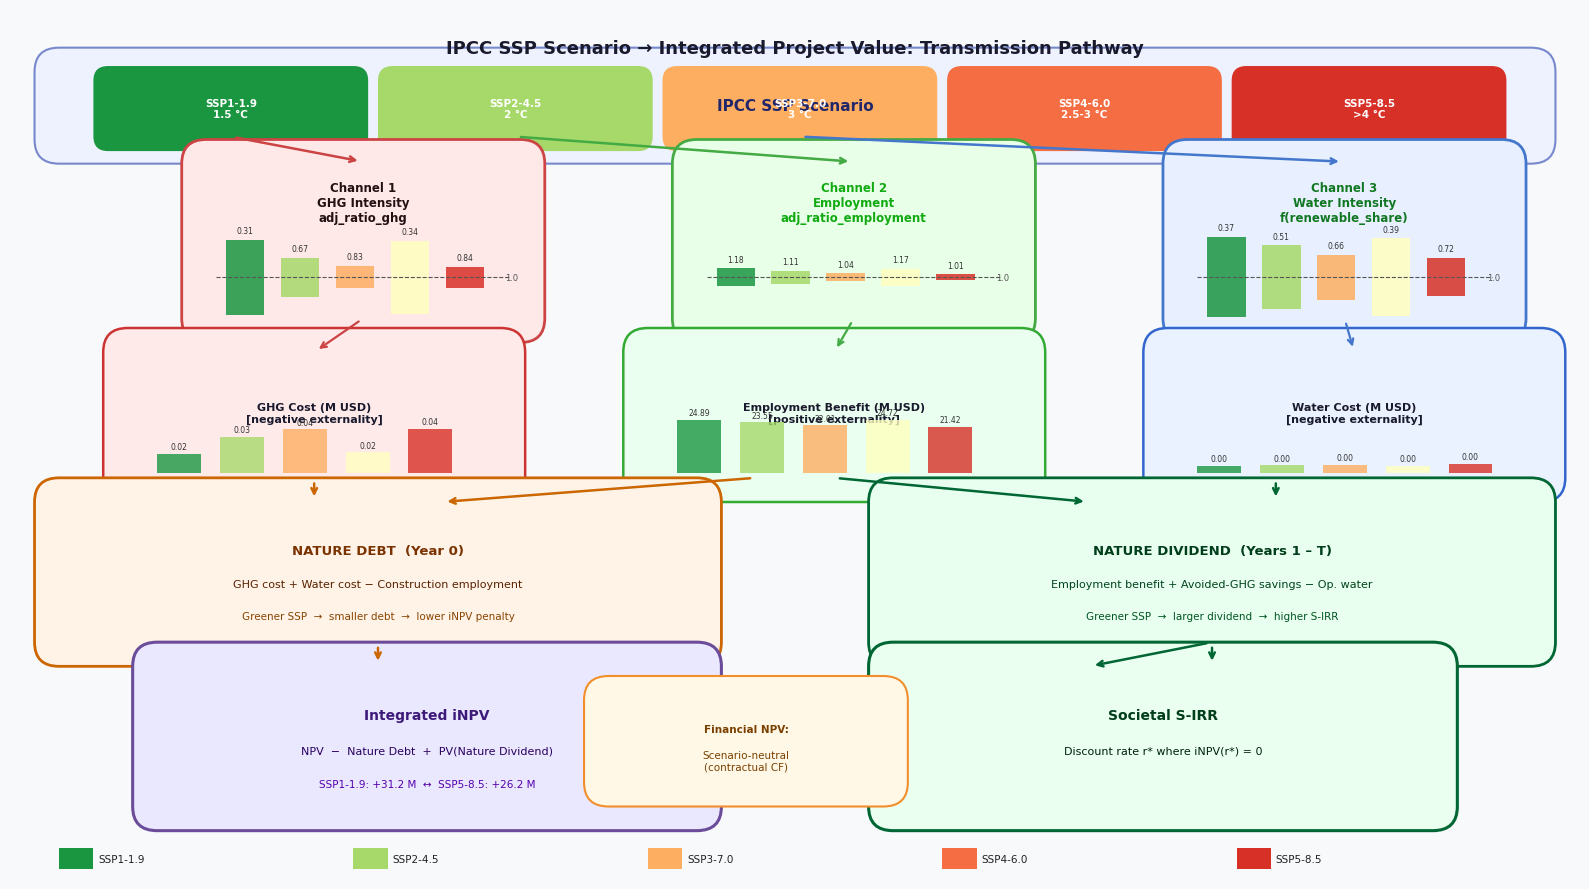

Pathway schematic saved → results/ipcc_pathway_Energy_Europe_2p0M.png


In [13]:
# ══════════════════════════════════════════════════════════════════
# PART G — IPCC PATHWAY SCHEMATIC  (Matplotlib flow diagram)
# Shows the three transmission channels from SSP to iNPV / S-IRR
# with per-scenario factor bars embedded in each channel box.
# ══════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig_sch, ax = plt.subplots(figsize=(16, 9), facecolor='#f8f9fb')
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#f8f9fb')

# ── colour helpers ────────────────────────────────────────────────
_ssp_list = list(SSP_RESULTS.keys()) if SSP_RESULTS else ALL_SSPS

def _box(x, y, w, h, fc='#e8f0ff', ec='#5577aa', lw=1.8, radius=0.25):
    p = FancyBboxPatch((x, y), w, h,
                       boxstyle=f'round,pad={radius}',
                       facecolor=fc, edgecolor=ec, linewidth=lw, zorder=3)
    ax.add_patch(p)

def _txt(x, y, s, fs=9, fw='normal', col='#1a1a2e', ha='center', va='center'):
    ax.text(x, y, s, fontsize=fs, fontweight=fw, color=col,
            ha=ha, va=va, zorder=4)

def _arrow(x1, y1, x2, y2, col='#555', lw=2.0, style='->', shrink=4):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=col, lw=lw,
                                shrinkA=shrink, shrinkB=shrink), zorder=5)

# ── Title ─────────────────────────────────────────────────────────
ax.text(8, 8.6, 'IPCC SSP Scenario → Integrated Project Value: Transmission Pathway',
        fontsize=13, fontweight='bold', ha='center', va='center',
        color='#1a1a2e', zorder=4)

# ── Row 1: SSP Scenario spectrum bar ─────────────────────────────
_box(0.5, 7.65, 15, 0.7, fc='#eef2ff', ec='#7788cc', lw=1.5)
_txt(8, 8.0, 'IPCC SSP Scenario', fs=11, fw='bold', col='#22266a')
# spectrum gradient boxes
_ssp_colors_list = ['#1a9641','#a6d96a','#fdae61','#f46d43','#d73027']
_ssp_labels_full = [
    'SSP1-1.9\n1.5 °C', 'SSP2-4.5\n2 °C',
    'SSP3-7.0\n3 °C', 'SSP4-6.0\n2.5-3 °C',
    'SSP5-8.5\n>4 °C'
]
for _i, (sc, sl) in enumerate(zip(_ssp_colors_list, _ssp_labels_full)):
    _bx = 1.0 + _i * 2.9
    _box(_bx, 7.68, 2.5, 0.58, fc=sc, ec='none', radius=0.15)
    _txt(_bx + 1.25, 7.97, sl, fs=7.5, fw='bold', col='white')

# ── Row 2: Three transmission channels ───────────────────────────
_channel_xs   = [2.0, 7.0, 12.0]
_channel_cols = ['#ffe8e8', '#e8ffe8', '#e8f0ff']
_channel_ecs  = ['#cc4444', '#44aa44', '#4477cc']
_channel_titles = [
    'Channel 1\nGHG Intensity\nadj_ratio_ghg',
    'Channel 2\nEmployment\nadj_ratio_employment',
    'Channel 3\nWater Intensity\nf(renewable_share)',
]
_factor_keys = ['factor_ghg', 'factor_emp', 'factor_wat']

for cx, fc, ec, ct, fk in zip(_channel_xs, _channel_cols, _channel_ecs,
                                _channel_titles, _factor_keys):
    _box(cx, 5.8, 3.2, 1.6, fc=fc, ec=ec, lw=2.0)
    _txt(cx + 1.6, 7.0, ct, fs=8.5, fw='bold',
         col=ec.replace('cc', '22').replace('44', '11'))

    # Mini factor bars inside each channel box
    if SSP_RESULTS:
        vals = [SSP_RESULTS[s][fk] for s in _ssp_list]
        _bar_w = 2.8 / max(len(vals), 1)
        _max_v = max(abs(v) for v in vals) + 0.01
        for _bi, (s, v) in enumerate(zip(_ssp_list, vals)):
            _bh = 0.9 * abs(v - 1.0) / _max_v  + 0.05
            _bc = SSP_COLORS.get(s, '#888')
            _bx2 = cx + 0.2 + _bi * _bar_w
            _by2 = 5.85 + (0.75 - _bh) / 2
            rect = plt.Rectangle((_bx2, _by2), _bar_w * 0.7, _bh,
                                  facecolor=_bc, edgecolor='none', alpha=0.85, zorder=5)
            ax.add_patch(rect)
            ax.text(_bx2 + _bar_w * 0.35, _by2 + _bh + 0.05,
                    f'{v:.2f}', fontsize=5.5, ha='center', va='bottom',
                    color='#333', zorder=6)
        # Baseline line at v=1.0
        _bline_y = 5.85 + 0.375
        ax.axhline(y=_bline_y, xmin=(cx + 0.1)/16, xmax=(cx + 3.1)/16,
                   color='#555', lw=0.8, ls='--', zorder=5)
        _txt(cx + 3.05, _bline_y, '1.0', fs=6, col='#555', ha='left', va='center')

    # Arrows from spectrum to channels
    _arrow(1.0 + list(_channel_xs).index(cx) * 2.9 + 1.25, 7.68,
           cx + 1.6, 7.42, col=_channel_ecs[list(_channel_xs).index(cx)], lw=1.8)

# ── Row 3: Monetary impacts ───────────────────────────────────────
_money_xs    = [1.2, 6.5, 11.8]
_money_cols  = ['#ffeaea', '#eafff0', '#eaf2ff']
_money_ecs   = ['#cc3333', '#33aa33', '#3366cc']
_money_lbls  = [
    'GHG Cost (M USD)\n[negative externality]',
    'Employment Benefit (M USD)\n[positive externality]',
    'Water Cost (M USD)\n[negative externality]',
]
_money_keys  = [('ghg_cost_m', -1), ('emp_ben_m', +1), ('water_cost_m', -1)]

for mx, mc, me, ml, (mk, sign) in zip(_money_xs, _money_cols, _money_ecs,
                                        _money_lbls, _money_keys):
    _box(mx, 4.15, 3.8, 1.3, fc=mc, ec=me, lw=1.8)
    _txt(mx + 1.9, 4.82, ml, fs=8, fw='bold', col='#1a1a2e')
    if SSP_RESULTS:
        vals_m = [SSP_RESULTS[s][mk] * sign for s in _ssp_list]
        _bar_w2 = 3.2 / max(len(vals_m), 1)
        _max_vm = max(abs(v) for v in vals_m) + 0.01
        for _bi2, (s, v) in enumerate(zip(_ssp_list, vals_m)):
            _bh2 = 0.5 * abs(v) / _max_vm + 0.05
            _bc2 = SSP_COLORS.get(s, '#888')
            _bx3 = mx + 0.3 + _bi2 * _bar_w2
            rect2 = plt.Rectangle((_bx3, 4.2), _bar_w2 * 0.7, _bh2,
                                   facecolor=_bc2, edgecolor='none', alpha=0.8, zorder=5)
            ax.add_patch(rect2)
            ax.text(_bx3 + _bar_w2*0.35, 4.2 + _bh2 + 0.03,
                    f'{v:.2f}', fontsize=5.5, ha='center', va='bottom',
                    color='#333', zorder=6)

# Arrows: channels → monetary
for ci, (cx, mx) in enumerate(zip(_channel_xs, _money_xs)):
    _arrow(cx + 1.6, 5.8, mx + 1.9, 5.45, col=_channel_ecs[ci], lw=1.6)

# ── Row 4: Nature Debt / Dividend ────────────────────────────────
_box(0.5, 2.45, 6.5, 1.45, fc='#fff3e8', ec='#cc6600', lw=2.0)
_txt(3.75, 3.4, 'NATURE DEBT  (Year 0)', fs=9.5, fw='bold', col='#7a3300')
_txt(3.75, 3.05,
     'GHG cost + Water cost − Construction employment',
     fs=8, col='#5a2200')
_txt(3.75, 2.72, 'Greener SSP  →  smaller debt  →  lower iNPV penalty', fs=7.5, col='#884400')

_box(9.0, 2.45, 6.5, 1.45, fc='#e8fff0', ec='#006633', lw=2.0)
_txt(12.25, 3.4, 'NATURE DIVIDEND  (Years 1 – T)', fs=9.5, fw='bold', col='#003d1a')
_txt(12.25, 3.05,
     'Employment benefit + Avoided-GHG savings − Op. water',
     fs=8, col='#00441d')
_txt(12.25, 2.72, 'Greener SSP  →  larger dividend  →  higher S-IRR', fs=7.5, col='#005522')

# Arrows: monetary → debt/dividend
_arrow(3.1, 4.15, 3.1, 3.9, col='#cc6600', lw=1.8)     # GHG cost → debt
_arrow(7.6, 4.15, 4.4, 3.9, col='#cc6600', lw=1.8)      # Water cost → debt (diagonal)
_arrow(8.4, 4.15, 11.0, 3.9, col='#006633', lw=1.8)     # Employment → dividend
_arrow(12.9, 4.15, 12.9, 3.9, col='#006633', lw=1.8)    # Water cost (op) → dividend

# ── Row 5: iNPV and S-IRR ────────────────────────────────────────
_box(1.5, 0.75, 5.5, 1.45, fc='#eae8ff', ec='#6b4c9a', lw=2.2)
_txt(4.25, 1.7,  'Integrated iNPV', fs=10, fw='bold', col='#3d1a7a')
_txt(4.25, 1.33, 'NPV  −  Nature Debt  +  PV(Nature Dividend)', fs=8, col='#2a0060')
if SSP_RESULTS:
    _best_ssp  = max(SSP_RESULTS.values(), key=lambda r: r['inpv'])['ssp']
    _worst_ssp = min(SSP_RESULTS.values(), key=lambda r: r['inpv'])['ssp']
    _best_v  = SSP_RESULTS[_best_ssp]['inpv']
    _worst_v = SSP_RESULTS[_worst_ssp]['inpv']
    _txt(4.25, 0.98,
         f'{_best_ssp}: {_best_v:+.1f} M  ↔  {_worst_ssp}: {_worst_v:+.1f} M',
         fs=7.5, col='#5500aa')

_box(9.0, 0.75, 5.5, 1.45, fc='#eafff0', ec='#006633', lw=2.2)
_txt(11.75, 1.7,  'Societal S-IRR', fs=10, fw='bold', col='#003d1a')
_txt(11.75, 1.33, 'Discount rate r* where iNPV(r*) = 0', fs=8, col='#002210')
if SSP_RESULTS:
    _sirr_vals = [(s, r['s_irr']) for s, r in SSP_RESULTS.items() if r['s_irr']]
    if _sirr_vals:
        _best_s  = max(_sirr_vals, key=lambda x: x[1])
        _worst_s = min(_sirr_vals, key=lambda x: x[1])
        _txt(11.75, 0.98,
             f'{_best_s[0]}: {_best_s[1]*100:.2f}%  ↔  {_worst_s[0]}: {_worst_s[1]*100:.2f}%',
             fs=7.5, col='#005522')

# Arrows: debt/dividend → outputs
_arrow(3.75, 2.45, 3.75, 2.2, col='#cc6600', lw=1.8)
_arrow(12.25, 2.45, 11.0, 2.2, col='#006633', lw=1.8)
_arrow(12.25, 2.45, 12.25, 2.2, col='#006633', lw=1.8)

# Annotation: NPV is scenario-neutral
_box(6.1, 1.0, 2.8, 0.85, fc='#fff8e7', ec='#f28e2b', lw=1.5)
_txt(7.5, 1.55, 'Financial NPV:', fs=7.5, fw='bold', col='#7a4000')
_txt(7.5, 1.22, 'Scenario-neutral\n(contractual CF)', fs=7.5, col='#7a4000')

# Legend
for _i, (s, c) in enumerate(zip(_ssp_list, _ssp_colors_list)):
    ax.add_patch(plt.Rectangle((0.5 + _i * 3.0, 0.1), 0.35, 0.22,
                                facecolor=c, edgecolor='none', zorder=4))
    ax.text(0.9 + _i * 3.0, 0.21, s, fontsize=7.5, va='center', color='#222', zorder=4)

plt.tight_layout()
_slug_sch = (
    f"ipcc_pathway_{SECTOR}_{REGION}_"
    f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}.png"
)
RESULTS_DIR.mkdir(exist_ok=True)
fig_sch.savefig(RESULTS_DIR / _slug_sch, dpi=150, bbox_inches='tight', facecolor='#f8f9fb')
plt.show()
print(f"Pathway schematic saved → results/{_slug_sch}")


## Plausibility Assessment — Model Assumptions vs Literature & Portfolio Data

This section cross-checks the notebook's key parameters against (a) the calibrated
portfolio results in `results/`, (b) published literature benchmarks, and (c) known
gaps identified in `source/onpv_formula_corrected.md`.

---

### What the Model Gets Right

| Dimension | Assessment |
|-----------|------------|
| SSP adjustment factors | Exact match to `scenario_adjustment.csv` (calibrated from OSeMOSYS/REMIND-MAgPIE) |
| dep_factor structure | Three-component (ENCORE + WWF WRF + SC sensitivity); range 0.33–1.67 matches literature |
| WACC greenium | 0.15–0.20% below conventional bonds (Shishlov et al. 2016; CBI 2023) correctly bounds ESG_MAX_DISCOUNT |
| Leontief IO tiers | Spectral radius ~0.52; convergence verified; EXIOBASE 3.8 calibrated |
| iNPV formula structure | Matches Atkinson & Mourato (2008); Nature Debt at t=0, Nature Dividend PV over T |

---

### Known Conservatism: Social Cost of Carbon (SCC)

The most material discrepancy is the SCC used to monetise GHG:

| Source | SCC (USD/tCO₂e) | Basis |
|--------|-------------------|-------|
| **WifOR Nordhaus DICE** | ~$19 | Nordhaus (2017) DICE model |
| **WifOR Paris-aligned** | ~$34 | Paris constraint DICE variant |
| **US EPA (2023)** | $51–$190 | Interagency Working Group |
| **IPCC AR6 WG3 central** | **$171** | Range $77–$284 |
| **High-end estimates** | $300–$1,000+ | Stern (2022); NGFS severe |

**Implication for this notebook:** All GHG-monetised figures (Nature Debt, iNPV
uplift) are **5–9x below IPCC AR6 WG3 central**. Under the IPCC central SCC:

- Nature Debt at construction would be ~$1.8 M (SSP1) vs ~$4.8 M (SSP5) per $100 M CAPEX
  *(vs ~$0.21 M / ~$0.57 M currently shown)*
- The iNPV uplift over NPV would be 3–6x larger
- S-IRR spreads across SSPs would widen materially

The Nordhaus baseline is used here because the WifOR value-factor files embed it;
switching to Paris-aligned SCC would only require changing `c_ghg` in Part A.

---

### Missing Channel: Legal Risk (L_legal)

Wetzer et al. (*Science* 383:152, 2024) decompose ONPV risk into three channels.
The legal channel is **not modelled** here:

```
Operating Income = Q(P - V_market - V_natural) - F - L_legal
                                                         ^
                                                   ABSENT from iNPV
```

L_legal represents attribution-based litigation liability — the risk that a project
is held legally responsible for nature loss it causes or accelerates. The Chevron
example in Wetzer et al. estimates this at the scale of **$8.5 trillion** for the
fossil-fuel sector globally. For infrastructure projects the magnitude is lower, but
the channel exists and grows as nature-related disclosure frameworks mature (TNFD, EU CSRD).

**Practical impact for Rail_EU_DEV:** Low, given `overall_high_risk = False` and
`top_dependency = flood_and_storm_protection` (regulatory, not extractive). However,
projects in higher-dependency sectors (Health_LATAM, Energy_BRAZIL) face more exposure.

---

### Formula Gaps (from onpv_formula_corrected.md P1–P8)

| Problem | Description | Direction of bias |
|---------|-------------|-------------------|
| **P2** | Linear scarcity cost vs convex (rising marginal cost at stress) | Understates cost at high stress |
| **P5** | L_legal absent | Understates downside risk |
| **P6** | Additive channel shocks vs multiplicative interaction effects | Understates combined risk |
| **P7** | Static WACC vs dynamic risk pricing | May over- or under-state WACC_adj |

All four gaps bias **downward** (i.e., iNPV > true ONPV under stress). The model is
internally consistent but should be read as an optimistic baseline rather than a
stress-tested risk figure.

---

### Net Assessment

| Category | Status |
|----------|--------|
| Financial NPV / IRR | Plausible; contractual cash flows are scenario-neutral |
| Nature Debt (construction GHG + water) | **Understated** by 5–9x vs IPCC WG3 SCC |
| Nature Dividend (employment + avoided GHG) | Directionally correct; magnitude conservative |
| S-IRR vs IRR spread | Correct direction; absolute levels compressed by low SCC |
| WACC adjustment | Plausible range; upper-bound matches green-bond greenium literature |
| SSP spread (iNPV range) | Pattern correct; scale will expand ~5–9x with IPCC SCC |

> **Recommendation:** For investment committee use, re-run with `c_ghg = 171.0`
> (IPCC WG3 central) or `c_ghg = 34.0` (Paris-aligned WifOR) and present
> the sensitivity as a scenario range alongside the Nordhaus baseline.


## Part F — Combined Cash Flow Table + Integrated Dashboard

A full year-by-year breakdown across the 30-year project life, distinguishing
the **bond period** (years 1–10) from **post-bond operations** (years 11–30),
followed by a static Matplotlib summary dashboard.

| Year | Financial CF | Monetised GHG | Monetised Social | Total Integrated CF |
|------|-------------|--------------|-----------------|--------------------|
| 0 (CAPEX) | −CAPEX | −GHG debt − Water debt | +Jobs (construct) | net |
| 1–10 (Bond) | Revenue − OPEX | +GHG savings − Op water | +Annual jobs | net |
| 11–30 (Post-bond) | Revenue − OPEX | +GHG savings − Op water | +Annual jobs | net |

In [14]:
# ══════════════════════════════════════════════════════════════════
# PART F — COMBINED CASH FLOW TABLE + INTEGRATED DASHBOARD
# ══════════════════════════════════════════════════════════════════

# ── Plotly: stacked bar of annual cash flow components ───────────
fig_cf = go.Figure()

fig_cf.add_trace(go.Bar(
    name="Financial CF",
    x=cf_df["Year"], y=cf_df["Financial CF (M$)"],
    marker_color=C_FIN, marker_opacity=0.85,
))
fig_cf.add_trace(go.Bar(
    name="Monetised GHG/Water",
    x=cf_df["Year"], y=cf_df["Monetised GHG/Water (M$)"],
    marker_color=C_GHG, marker_opacity=0.85,
))
fig_cf.add_trace(go.Bar(
    name="Monetised Social (Employment)",
    x=cf_df["Year"], y=cf_df["Monetised Social (M$)"],
    marker_color=C_EMP, marker_opacity=0.85,
))
fig_cf.add_trace(go.Scatter(
    name="Total Integrated CF",
    x=cf_df["Year"], y=cf_df["Total Integrated CF (M$)"],
    mode="lines+markers",
    line=dict(color=C_TOT, width=2.5),
    marker=dict(size=5),
))
fig_cf.add_vline(x=BOND_YEARS + 0.5, line_color="#f28e2b", line_dash="dot",
                  annotation_text=f"Bond end (Yr {BOND_YEARS})",
                  annotation_position="top right")
fig_cf.add_hline(y=0, line_color="#555", line_width=1.2)

fig_cf.update_layout(
    barmode="relative",
    title=dict(
        text=(f"<b>Combined Cash Flow Table — {fmt_capex(CAPEX_USD)} · "
              f"{COUNTRY} ({REGION}) · {SECTOR} · {sc_label}</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"Bond: {BOND_YEARS} yrs · Project: {PROJECT_YEARS} yrs · "
              f"WACC_base: {WACC_BASE*100:.2f}% · WACC_adj: {WACC_ADJUSTED*100:.3f}%</span>"),
        x=0.01, xanchor="left", font=dict(size=14),
    ),
    xaxis_title="Year", yaxis_title="M USD",
    height=500, margin=dict(l=20, r=20, t=130, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
    legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center"),
)
display(HTML(fig_cf.to_html(full_html=False, include_plotlyjs="cdn")))

# ── Full table (condensed): show year 0, years 1-5, bond end, post-bond ──
sample_rows = [0] + list(range(1, min(6, PROJECT_YEARS+1))) + [BOND_YEARS, PROJECT_YEARS]
sample_rows = sorted(set(sample_rows))
display(HTML("<b>Representative rows from the Combined Cash Flow Table</b>"))
display(
    cf_df[cf_df["Year"].isin(sample_rows)].style
    .format({
        "Financial CF (M$)": "{:+.2f}",
        "Monetised GHG/Water (M$)": "{:+.3f}",
        "Monetised Social (M$)": "{:+.3f}",
        "Total Integrated CF (M$)": "{:+.2f}",
    })
    .set_caption("Combined Cash Flow Table (M USD)")
    .applymap(
        lambda v: "color:#2ca02c" if isinstance(v, (int, float)) and v > 0 else
                  ("color:#d62728" if isinstance(v, (int, float)) and v < 0 else ""),
        subset=["Financial CF (M$)", "Monetised GHG/Water (M$)",
                "Monetised Social (M$)", "Total Integrated CF (M$)"]
    )
)

,Year,Financial CF (M$),Monetised GHG/Water (M$),Monetised Social (M$),Total Integrated CF (M$)
0,0,-2.00,+0.036,+23.554,+21.59
1,1,+0.12,-0.390,+0.942,+0.67
2,2,+0.12,-0.390,+0.942,+0.67
3,3,+0.12,-0.390,+0.942,+0.67
4,4,+0.12,-0.390,+0.942,+0.67
5,5,+0.12,-0.390,+0.942,+0.67
20,20,+0.12,-0.390,+0.942,+0.67


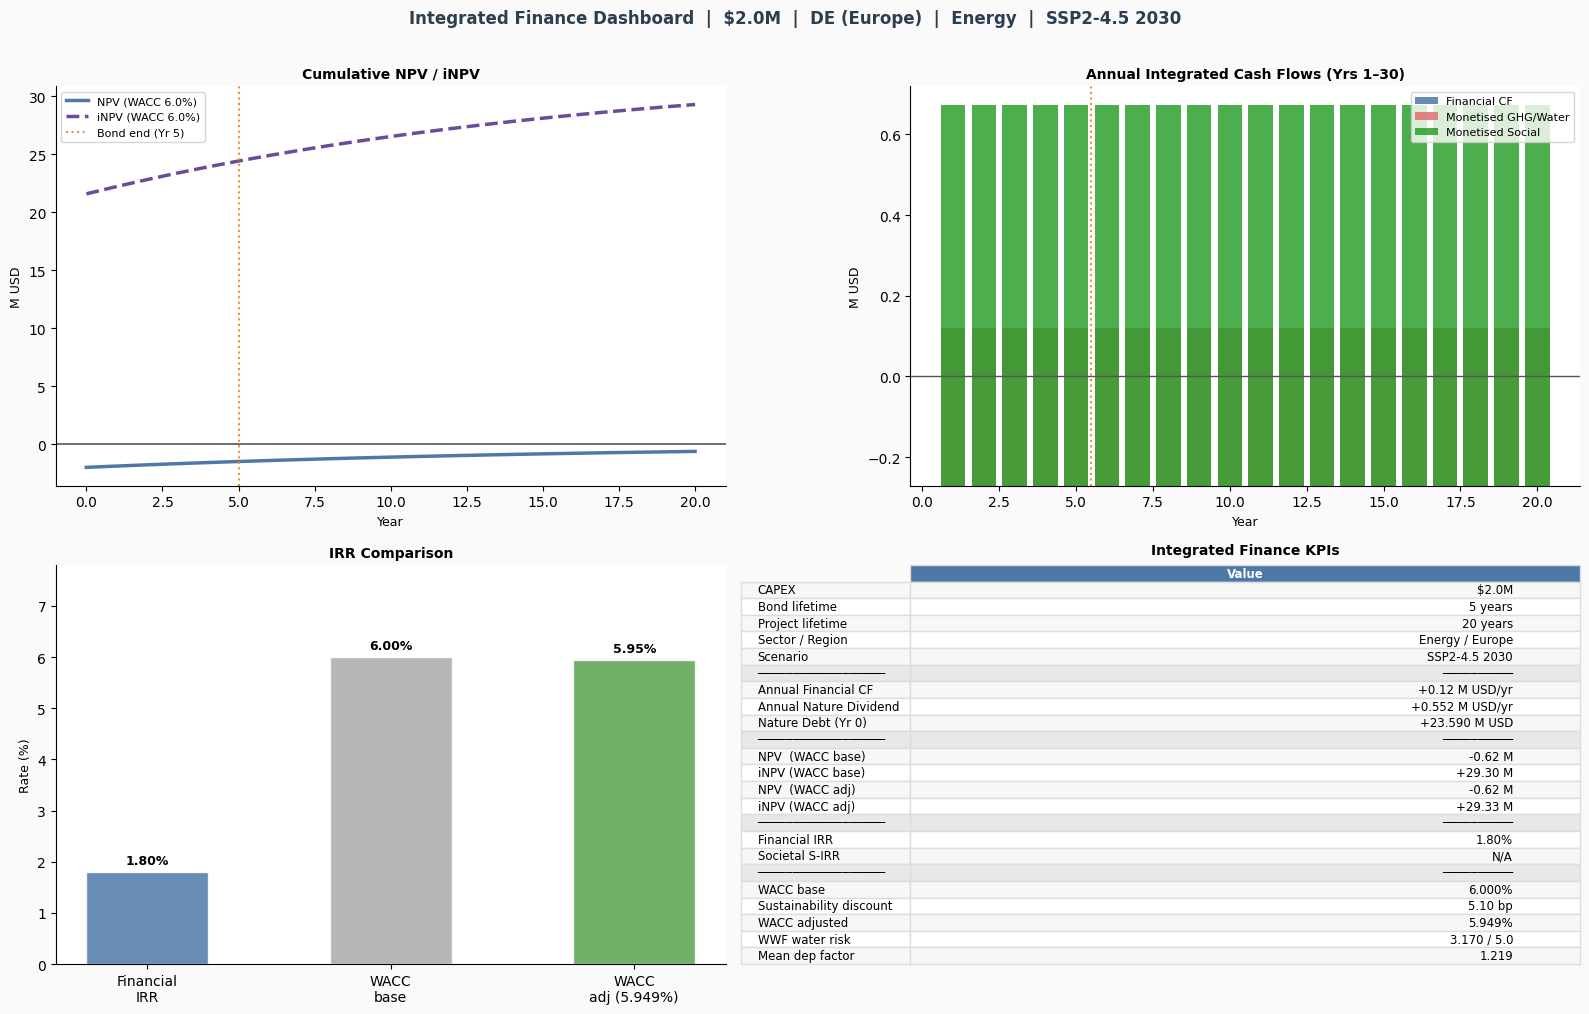

Dashboard saved → results/integrated_finance_Energy_Europe_2p0M_SSP245.png


In [15]:
# ══════════════════════════════════════════════════════════════════
# PART F (cont.) — STATIC MATPLOTLIB INTEGRATED FINANCE DASHBOARD
# 4-panel: (1) Cumulative NPV/iNPV  (2) Annual CF waterfall (bar)
#           (3) IRR comparison        (4) Summary KPI table
# ══════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

fig_dash, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#fafafa")
fig_dash.suptitle(
    (f"Integrated Finance Dashboard  |  {fmt_capex(CAPEX_USD)}  |  "
     f"{COUNTRY} ({REGION})  |  {SECTOR}  |  {sc_label}"),
    fontsize=12, fontweight="bold", y=1.01, color="#2c3e50",
)

# ── Panel 1: Cumulative NPV / iNPV over full project life ─────────
ax1 = axes[0, 0]
_yrs   = list(range(PROJECT_YEARS + 1))
ax1.plot(_yrs, cum_npv,  label=f"NPV (WACC {WACC_BASE*100:.1f}%)",
         color=C_FIN,  lw=2.5)
ax1.plot(_yrs, cum_inpv, label=f"iNPV (WACC {WACC_BASE*100:.1f}%)",
         color=C_TOT, lw=2.5, ls="--")
ax1.axhline(0, color="#555", lw=1.2)
ax1.axvline(BOND_YEARS, color="#f28e2b", lw=1.5, ls=":",
            label=f"Bond end (Yr {BOND_YEARS})")
ax1.set_xlabel("Year", fontsize=9)
ax1.set_ylabel("M USD", fontsize=9)
ax1.set_title("Cumulative NPV / iNPV", fontsize=10, fontweight="bold")
ax1.legend(fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Panel 2: Stacked annual integrated CF (years 1-30) ────────────
ax2 = axes[0, 1]
_yr_range = list(range(1, PROJECT_YEARS + 1))
_fc   = cf_df[cf_df["Year"] > 0]["Financial CF (M$)"].values
_mg   = cf_df[cf_df["Year"] > 0]["Monetised GHG/Water (M$)"].values
_ms   = cf_df[cf_df["Year"] > 0]["Monetised Social (M$)"].values

ax2.bar(_yr_range, _fc, label="Financial CF",       color=C_FIN,  alpha=0.85, edgecolor="none")
ax2.bar(_yr_range, _mg, label="Monetised GHG/Water", color=C_GHG, alpha=0.85, edgecolor="none",
        bottom=_fc)
ax2.bar(_yr_range, _ms, label="Monetised Social",    color=C_EMP, alpha=0.85, edgecolor="none",
        bottom=_fc + _mg)
ax2.axvline(BOND_YEARS + 0.5, color="#f28e2b", lw=1.5, ls=":")
ax2.axhline(0, color="#555", lw=1)
ax2.set_xlabel("Year", fontsize=9)
ax2.set_ylabel("M USD", fontsize=9)
ax2.set_title("Annual Integrated Cash Flows (Yrs 1–30)", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8, loc="upper right")
ax2.spines[["top", "right"]].set_visible(False)

# ── Panel 3: IRR comparison bar ───────────────────────────────────
ax3 = axes[1, 0]
irr_plot_labels = []
irr_plot_vals   = []
irr_plot_cols   = []
if FIN_IRR is not None:
    irr_plot_labels.append(f"Financial\nIRR"); irr_plot_vals.append(FIN_IRR*100); irr_plot_cols.append(C_FIN)
irr_plot_labels.append(f"WACC\nbase"); irr_plot_vals.append(WACC_BASE*100); irr_plot_cols.append("#aaa")
irr_plot_labels.append(f"WACC\nadj ({WACC_ADJUSTED*100:.3f}%)"); irr_plot_vals.append(WACC_ADJUSTED*100); irr_plot_cols.append("#59a14f")
if S_IRR is not None:
    irr_plot_labels.append(f"Societal\nS-IRR"); irr_plot_vals.append(S_IRR*100); irr_plot_cols.append(C_TOT)

bars3 = ax3.bar(irr_plot_labels, irr_plot_vals, color=irr_plot_cols, alpha=0.85,
                edgecolor="white", width=0.5)
for b, v in zip(bars3, irr_plot_vals):
    ax3.text(b.get_x() + b.get_width()/2, v + 0.1,
             f"{v:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_ylabel("Rate (%)", fontsize=9)
ax3.set_title("IRR Comparison", fontsize=10, fontweight="bold")
ax3.spines[["top", "right"]].set_visible(False)
ax3.set_ylim(0, max(irr_plot_vals) * 1.3)

# ── Panel 4: KPI summary table ────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis("off")

def _fmtv(v, fmt="{:+.2f} M"):
    if v is None: return "N/A"
    return fmt.format(v)

kpi_rows = [
    ["Parameter",              "Value"],
    ["CAPEX",                  fmt_capex(CAPEX_USD)],
    ["Bond lifetime",          f"{BOND_YEARS} years"],
    ["Project lifetime",       f"{PROJECT_YEARS} years"],
    ["Sector / Region",        f"{SECTOR} / {REGION}"],
    ["Scenario",               sc_label],
    ["──────────────────",     "──────────"],
    ["Annual Financial CF",    f"{ANNUAL_FIN_CF_MUSD:+.2f} M USD/yr"],
    ["Annual Nature Dividend", f"{S_ANNUAL_MUSD:+.3f} M USD/yr"],
    ["Nature Debt (Yr 0)",     f"{-S_CONSTR_NET_MUSD:+.3f} M USD"],
    ["──────────────────",     "──────────"],
    ["NPV  (WACC base)",       _fmtv(NPV_BASE)],
    ["iNPV (WACC base)",       _fmtv(iNPV_BASE)],
    ["NPV  (WACC adj)",        _fmtv(NPV_ADJ)],
    ["iNPV (WACC adj)",        _fmtv(iNPV_ADJ)],
    ["──────────────────",     "──────────"],
    ["Financial IRR",          f"{FIN_IRR*100:.2f}%" if FIN_IRR else "N/A"],
    ["Societal S-IRR",         f"{S_IRR*100:.2f}%"  if S_IRR   else "N/A"],
    ["──────────────────",     "──────────"],
    ["WACC base",              f"{WACC_BASE*100:.3f}%"],
    ["Sustainability discount",f"{SUSTAINABILITY_DISCOUNT*10000:.2f} bp"],
    ["WACC adjusted",          f"{WACC_ADJUSTED*100:.3f}%"],
    ["WWF water risk",         f"{wwf_water:.3f} / 5.0"],
    ["Mean dep factor",        f"{mean_dep:.3f}"],
]

tbl = ax4.table(
    cellText=[r[1:] for r in kpi_rows[1:]],
    rowLabels=[r[0] for r in kpi_rows[1:]],
    colLabels=[kpi_rows[0][1]],
    cellLoc="right", rowLoc="left", loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ddd")
    if r == 0:
        cell.set_facecolor("#4e79a7")
        cell.set_text_props(color="white", fontweight="bold")
    elif kpi_rows[r][0].startswith("──"):
        cell.set_facecolor("#e8e8e8")
    else:
        cell.set_facecolor("#f7f7f7" if r % 2 == 1 else "white")
ax4.set_title("Integrated Finance KPIs", fontsize=10, fontweight="bold", pad=8)

plt.tight_layout()
_slug = (
    f"integrated_finance_{SECTOR}_{REGION}_"
    f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}"
    f"{'_'+SCENARIO.replace('.','').replace('-','') if SCENARIO else ''}.png"
)
RESULTS_DIR.mkdir(exist_ok=True)
fig_dash.savefig(RESULTS_DIR / _slug, dpi=150, bbox_inches="tight", facecolor="#fafafa")
plt.show()
print(f"Dashboard saved → results/{_slug}")